<a href="https://colab.research.google.com/github/leticiasdrummond/Modelos-Base/blob/main/optimize_power_schedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade Avaliativa II**

# **Atividade Intividual de Economia de Energia II**

- Letícia Sampaio Drummond Valladares RA:298985
- Professor: Arnaldo Walter

Junho de 2026

---

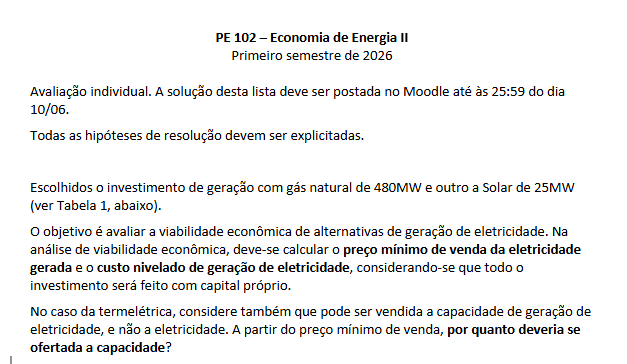

## Economic Evaluation of Power Generation Projects

This section addresses the economic evaluation of two power generation investment alternatives: a natural gas plant (480MW) and a solar plant (25MW). The objective is to calculate the minimum selling price of electricity, the Levelized Cost of Electricity (LCOE), and the minimum selling price for capacity for the natural gas plant.

### 1. Parameter Definition

First, let's define all the input parameters provided in the problem description, including the chosen discount rate. The problem states that the discount rate should be justified; for private investments in the energy sector, rates typically range from 8% to 15% depending on risk. Given the absence of specific risk profiles, a **10%** discount rate is chosen as a reasonable and commonly used benchmark for projects with moderate risk, balancing investor returns and project viability.

**Assumptions:**
*   **Capacity Factor (FC anual %)**: Interpreted as the annual capacity factor (or load factor) for both technologies, representing the actual output over a period as a percentage of the maximum possible output.
*   **Monetary Units**: All calculations will be performed in **USD**, as all provided cost data is in US$. If an exchange rate were provided, conversions for BRL-specific thresholds (like the IR profit threshold) would be applied.
*   **Hours per Year**: Assumed to be 8760 hours (24 hours * 365 days).
*   **Inflation**: Not specified, so all costs and revenues are assumed to be in real terms (constant dollars), consistent with a real discount rate.

In [ ]:
import pandas as pd

# --- Common Parameters ---
discount_rate = 0.10 # 10% chosen as a reasonable rate for private energy investments
hours_per_year = 8760

# --- Natural Gas Plant Parameters ---
capacity_gas_mw = 480 # MW
overnight_costs_gas_usd_per_kw = 739 # US$/kW
efficiency_gas_percent = 0.34 # 34% (electrical efficiency)
o_m_gas_usd_per_mwh = 16.71 # US$/MWh
capacity_factor_gas_percent = 0.30 # 30% (interpreted as annual capacity factor)
fuel_cost_gas_usd_per_gj = 5.0 # US$/GJ
construction_time_gas_years = 3 # Years
operational_life_gas_years = 30 # Years

# Construction cost fractions for Natural Gas (years before operation start: -2, -1, 0)
# Year 0 here means the year of commissioning, not end of year 0.
# The problem states '-2', '-1', '0' as years before the start of operation. So, -2 is 2 years before, -1 is 1 year before, 0 is the start year.
construction_fractions_gas = {
    'Year -2': 0.17,
    'Year -1': 0.49,
    'Year 0': 0.34 # Year of commissioning / start of operation
}

# --- Solar Plant Parameters ---
capacity_solar_mw = 25 # MW
overnight_costs_solar_usd_per_kw = 1197 # US$/kW
o_m_solar_usd_per_mwh = 6.48 # US$/MWh
capacity_factor_solar_percent = 0.31 # 31% (interpreted as annual capacity factor)
construction_time_solar_years = 2 # Years
operational_life_solar_years = 25 # Years

# Construction cost fractions for Solar (years before operation start: -1, 0)
construction_fractions_solar = {
    'Year -1': 0.40,
    'Year 0': 0.60 # Year of commissioning / start of operation
}

# --- Tax and Charges Parameters (Common for both, assuming USD equivalent for BRL thresholds) ---
tax_confins = 0.0760 # 7.60% on gross revenue
tax_pis = 0.0165 # 1.65% on gross revenue
tax_tfsee = 0.0050 # 0.50% on gross revenue
tax_csll = 0.090 # 9.0% on real profit
tax_ir_base = 0.150 # 15.0% on real profit
tax_ir_additional = 0.100 # 10.0% additional on profit exceeding threshold
ir_profit_threshold_monthly_usd = 20000.0 # US$20,000 (assuming 1 USD = 1 BRL for simplicity, as no exchange rate given)

print("Parameters defined successfully.")

Parameters defined successfully.


### 2. Investment Cost Calculation

This section calculates the total investment cost for both the natural gas and solar power plants. The calculation will consider the overnight costs, the capacity, and the construction schedule, applying the discount rate to account for the time value of money during the construction phase. Since the problem specifies "overnight costs" and then lists construction fractions across multiple years, it implies a need to discount these construction expenditures back to a common point (e.g., the start of construction or the commercial operation date) to get a time-valued total investment.

We will calculate the present value of all construction expenditures at the Commercial Operation Date (COD), which is 'Year 0' in the provided construction fractions. This approach is consistent with how project finance often evaluates total capital expenditure.

First, let's calculate the total overnight cost (total capital expenditure before considering construction period financing) for each plant:

In [ ]:
# Total Overnight Costs
total_overnight_costs_gas = capacity_gas_mw * 1000 * overnight_costs_gas_usd_per_kw # MW to kW, then to total USD
total_overnight_costs_solar = capacity_solar_mw * 1000 * overnight_costs_solar_usd_per_kw # MW to kW, then to total USD

print(f"Total Overnight Costs for Natural Gas Plant: US$ {total_overnight_costs_gas:,.2f}")
print(f"Total Overnight Costs for Solar Plant: US$ {total_overnight_costs_solar:,.2f}")

# Now, calculate the total investment cost including construction period financing (time value of money)
# We discount/compound all expenditures to the Commercial Operation Date (COD), which is 'Year 0'.

# Natural Gas Plant
# Construction years are -2, -1, 0. 'Year 0' is the COD. '-1' means 1 year before COD, '-2' means 2 years before COD.
# We compound costs incurred before COD to COD.

# Determine the construction years and their fractions in chronological order
# Example: if construction_time_gas_years = 3, and fractions for -2, -1, 0. The effective years before COD are 2, 1, 0.

construction_pv_gas = 0
for year_str, fraction in construction_fractions_gas.items():
    year_offset = int(year_str.split(' ')[1]) # Extracts -2, -1, 0
    # The formula (1 + r)^n means compounding for 'n' years forward.
    # For 'Year -2', it means 2 years *before* COD, so it needs to be compounded for 2 years.
    # For 'Year -1', it means 1 year *before* COD, so it needs to be compounded for 1 year.
    # For 'Year 0', it is at COD, so it needs to be compounded for 0 years.
    years_to_compound = -year_offset
    construction_pv_gas += total_overnight_costs_gas * fraction * ((1 + discount_rate)**years_to_compound)

# Solar Plant
construction_pv_solar = 0
for year_str, fraction in construction_fractions_solar.items():
    year_offset = int(year_str.split(' ')[1]) # Extracts -1, 0
    years_to_compound = -year_offset
    construction_pv_solar += total_overnight_costs_solar * fraction * ((1 + discount_rate)**years_to_compound)


total_investment_cost_gas = construction_pv_gas
total_investment_cost_solar = construction_pv_solar

print(f"Total Investment Cost (at COD) for Natural Gas Plant: US$ {total_investment_cost_gas:,.2f}")
print(f"Total Investment Cost (at COD) for Solar Plant: US$ {total_investment_cost_solar:,.2f}")

Total Overnight Costs for Natural Gas Plant: US$ 354,720,000.00
Total Overnight Costs for Solar Plant: US$ 29,925,000.00
Total Investment Cost (at COD) for Natural Gas Plant: US$ 384,764,784.00
Total Investment Cost (at COD) for Solar Plant: US$ 31,122,000.00


### 3. Annual Electricity Generation and Costs

This section calculates the annual electricity generation for both plants and then proceeds to calculate the annual operating and fuel costs. These values are crucial for determining the Levelized Cost of Electricity (LCOE).

In [ ]:
# --- Annual Electricity Generation ---
# Annual generation (MWh) = Capacity (MW) * Capacity Factor * Hours per Year
annual_generation_gas_mwh = capacity_gas_mw * capacity_factor_gas_percent * hours_per_year
annual_generation_solar_mwh = capacity_solar_mw * capacity_factor_solar_percent * hours_per_year

print(f"Annual Electricity Generation for Natural Gas Plant: {annual_generation_gas_mwh:,.2f} MWh")
print(f"Annual Electricity Generation for Solar Plant: {annual_generation_solar_mwh:,.2f} MWh")

# --- Annual O&M Costs ---
# Annual O&M (USD) = O&M per MWh * Annual Generation (MWh)
annual_o_m_gas_usd = o_m_gas_usd_per_mwh * annual_generation_gas_mwh
annual_o_m_solar_usd = o_m_solar_usd_per_mwh * annual_generation_solar_mwh

print(f"Annual O&M Costs for Natural Gas Plant: US$ {annual_o_m_gas_usd:,.2f}")
print(f"Annual O&M Costs for Solar Plant: US$ {annual_o_m_solar_usd:,.2f}")

# --- Annual Fuel Costs (Natural Gas Plant only) ---
# Energy content of natural gas is typically in GJ. Efficiency is a key factor.
# Fuel consumption = (Annual Generation MWh * 3.6 GJ/MWh) / Efficiency
# Annual Fuel Cost = Fuel Consumption * Fuel Cost per GJ

# Convert MWh to GJ for fuel calculation (1 MWh = 3.6 GJ)
annual_generation_gas_gj = annual_generation_gas_mwh * 3.6

# Fuel required in GJ, considering efficiency
fuel_required_gas_gj = annual_generation_gas_gj / efficiency_gas_percent

# Annual Fuel Cost
annual_fuel_cost_gas_usd = fuel_required_gas_gj * fuel_cost_gas_usd_per_gj

print(f"Annual Fuel Costs for Natural Gas Plant: US$ {annual_fuel_cost_gas_usd:,.2f}")

Annual Electricity Generation for Natural Gas Plant: 1,261,440.00 MWh
Annual Electricity Generation for Solar Plant: 67,890.00 MWh
Annual O&M Costs for Natural Gas Plant: US$ 21,078,662.40
Annual O&M Costs for Solar Plant: US$ 439,927.20
Annual Fuel Costs for Natural Gas Plant: US$ 66,782,117.65


### 4. Levelized Cost of Electricity (LCOE) Calculation

The Levelized Cost of Electricity (LCOE) represents the average revenue per unit of electricity generated that would be required to recover the costs of building and operating a generating plant over an assumed financial life and duty cycle. It is often cited as a convenient summary measure of the overall competitiveness of different generating technologies.

The basic formula for LCOE (in \$/MWh) is:

$$ LCOE = \frac{\sum_{t=1}^{n} \frac{I_t + O\&M_t + F_t}{(1+r)^t}}{\sum_{t=1}^{n} \frac{E_t}{(1+r)^t}} $$

Where:
*   $I_t$: Investment expenditures in year $t$
*   $O\&M_t$: Operations and maintenance expenditures in year $t$
*   $F_t$: Fuel expenditures in year $t$
*   $E_t$: Electricity generated in year $t$
*   $r$: Discount rate
*   $n$: Operational life of the plant

Since we are assuming constant annual O&M, fuel costs, and electricity generation over the operational life, and all investment costs are captured at year 0 (COD), the formula simplifies for the annual costs/generation:

$$ LCOE = \frac{Total Investment Cost + \sum_{t=1}^{n} \frac{Annual O\&M + Annual Fuel}{(1+r)^t}}{\sum_{t=1}^{n} \frac{Annual Generation}{(1+r)^t}} $$

The summation terms in the denominator and numerator represent the present value of a uniform series of payments/receipts, which can be simplified using the Present Value Interest Factor of an Annuity (PVIFA) formula:

$$ PVIFA = \frac{1 - (1+r)^{-n}}{r} $$

So, the LCOE can be calculated as:

$$ LCOE = \frac{Total Investment Cost + (Annual O\&M + Annual Fuel) \times PVIFA}{Annual Generation \times PVIFA} $$

In [ ]:
# Function to calculate Present Value Interest Factor of an Annuity (PVIFA)
def calculate_pvifa(rate, periods):
    if rate == 0:
        return periods
    return (1 - (1 + rate)**(-periods)) / rate

# --- LCOE for Natural Gas Plant ---
pvifa_gas = calculate_pvifa(discount_rate, operational_life_gas_years)

present_value_opex_gas = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) * pvifa_gas
present_value_generation_gas = annual_generation_gas_mwh * pvifa_gas

lcoe_gas_usd_per_mwh = (total_investment_cost_gas + present_value_opex_gas) / present_value_generation_gas

print(f"Levelized Cost of Electricity (LCOE) for Natural Gas Plant: US$ {lcoe_gas_usd_per_mwh:,.2f}/MWh")

# --- LCOE for Solar Plant ---
pvifa_solar = calculate_pvifa(discount_rate, operational_life_solar_years)

# Solar plant has no fuel costs
present_value_opex_solar = annual_o_m_solar_usd * pvifa_solar
present_value_generation_solar = annual_generation_solar_mwh * pvifa_solar

lcoe_solar_usd_per_mwh = (total_investment_cost_solar + present_value_opex_solar) / present_value_generation_solar

print(f"Levelized Cost of Electricity (LCOE) for Solar Plant: US$ {lcoe_solar_usd_per_mwh:,.2f}/MWh")

Levelized Cost of Electricity (LCOE) for Natural Gas Plant: US$ 102.01/MWh
Levelized Cost of Electricity (LCOE) for Solar Plant: US$ 56.98/MWh


### 5. Minimum Selling Price of Electricity (Preço Mínimo de Venda)

To determine the minimum selling price of electricity, we need to find the price ($P$) that makes the Net Present Value (NPV) of the project equal to zero over its operational life. This calculation will account for depreciation, annual operating costs, fuel costs (for natural gas), and the specified tax structure, including the additional income tax.

We will use a new discount rate of **9%** as specified for this part of the analysis.

**Key components of the calculation:**
*   **Annual Energy Production ($E_{anual}$)**: Already calculated.
*   **Depreciation**: Calculated linearly based on `CAPEX Overnight` over the operational life.
*   **Gross Revenue ($Receita Bruta$)**: $P \times E_{anual}$
*   **Net Revenue ($Receita L\u00edquida$)**: Gross Revenue after deducting PIS, COFINS, and TFSEE.
*   **Costs ($Custos$)**: Annual O&M + Annual Fuel.
*   **Real Profit ($Lucro Real$)**: Net Revenue - Costs - Depreciation.
*   **Taxes**: IRPJ (15%), CSLL (9%), and Additional IR (10% on profit exceeding R$20,000/month, or $240,000/year assuming 1 USD = 1 BRL).
*   **Cash Flow ($FC_t$)**: Calculated for each year of operation.
*   **NPV**: Sum of discounted cash flows, set to zero to solve for $P$.

First, let's update the discount rate for this specific calculation and define the annual depreciation.

In [ ]:
from scipy.optimize import fsolve

# Update discount rate as per user's instruction for this specific calculation
discount_rate_pvm = 0.09 # 9% per year

# --- Calculate Annual Depreciation ---
# Depreciation is based on Overnight CAPEX / Operational Life
depreciation_gas = total_overnight_costs_gas / operational_life_gas_years
depreciation_solar = total_overnight_costs_solar / operational_life_solar_years

print(f"Annual Depreciation for Natural Gas Plant: US$ {depreciation_gas:,.2f}")
print(f"Annual Depreciation for Solar Plant: US$ {depreciation_solar:,.2f}")

# Combine the gross revenue taxes
total_gross_revenue_taxes_rate = tax_confins + tax_pis + tax_tfsee

# Annual threshold for additional IR (monthly * 12)
ir_profit_threshold_annual_usd = ir_profit_threshold_monthly_usd * 12

def calculate_npv_for_price(price_per_mwh, plant_type):
    # Retrieve plant-specific parameters
    if plant_type == 'gas':
        total_investment_cost = total_investment_cost_gas
        annual_generation_mwh = annual_generation_gas_mwh
        annual_o_m_usd = annual_o_m_gas_usd
        annual_fuel_cost_usd = annual_fuel_cost_gas_usd
        operational_life_years = operational_life_gas_years
        depreciation = depreciation_gas
    elif plant_type == 'solar':
        total_investment_cost = total_investment_cost_solar
        annual_generation_mwh = annual_generation_solar_mwh
        annual_o_m_usd = annual_o_m_solar_usd
        annual_fuel_cost_usd = 0 # Solar has no fuel costs
        operational_life_years = operational_life_solar_years
        depreciation = depreciation_solar
    else:
        raise ValueError("Invalid plant_type. Must be 'gas' or 'solar'.")

    # --- Calculate Annual Cash Flow Components ---
    gross_revenue = price_per_mwh * annual_generation_mwh
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price (P) that makes NPV = 0 ---
# We need an initial guess for fsolve. A good starting point could be the LCOE or higher.
initial_guess_gas = lcoe_gas_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit
initial_guess_solar = lcoe_solar_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit

# Use fsolve to find the root (price where NPV is zero)
min_selling_price_gas = fsolve(calculate_npv_for_price, initial_guess_gas, args=('gas',))[0]
min_selling_price_solar = fsolve(calculate_npv_for_price, initial_guess_solar, args=('solar',))[0]

print(f"\nMinimum Selling Price for Natural Gas Plant: US$ {min_selling_price_gas:,.2f}/MWh")
print(f"Minimum Selling Price for Solar Plant: US$ {min_selling_price_solar:,.2f}/MWh")

Annual Depreciation for Natural Gas Plant: US$ 11,824,000.00
Annual Depreciation for Solar Plant: US$ 1,197,000.00

Minimum Selling Price for Natural Gas Plant: US$ 121.64/MWh
Minimum Selling Price for Solar Plant: US$ 74.87/MWh


### 6. Minimum Selling Price for Capacity (Natural Gas Plant)

For the natural gas thermal plant, the problem also asks for the minimum price at which its generation capacity should be offered, considering that revenue would come from capacity sales rather than electricity sales. This means the plant would sell its installed capacity (MW) for a certain price per unit of capacity (e.g., US$/MW/year) and the revenue stream would be independent of actual electricity generation, but all operational costs and taxes would still apply.

To calculate this, we will again use the NPV = 0 criterion. The main change in the cash flow model will be in how the gross revenue is calculated:

$$ Receita Bruta = Pre\u00e7o da Capacidade (US\$/MW/ano) \times Capacidade (MW) $$

The remaining cost and tax components will be applied as before, with the same 9% discount rate.

In [ ]:
from scipy.optimize import fsolve

def calculate_npv_for_capacity_price(capacity_price_per_mw_year):
    # Parameters for Natural Gas Plant
    total_investment_cost = total_investment_cost_gas
    capacity_mw = capacity_gas_mw
    annual_o_m_usd = annual_o_m_gas_usd
    annual_fuel_cost_usd = annual_fuel_cost_gas_usd
    operational_life_years = operational_life_gas_years
    depreciation = depreciation_gas

    # --- Calculate Annual Cash Flow Components ---
    # Gross revenue now comes from capacity sales
    gross_revenue = capacity_price_per_mw_year * capacity_mw
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price for Capacity (P_capacity) that makes NPV = 0 ---
# We need an initial guess for fsolve. Let's estimate based on total annual costs / capacity.
estimated_annual_operating_cost_per_mw = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) / capacity_gas_mw
initial_guess_capacity_price = (estimated_annual_operating_cost_per_mw + (total_investment_cost_gas / operational_life_gas_years / capacity_gas_mw)) * 2 # heuristic guess

min_selling_price_capacity_gas = fsolve(calculate_npv_for_capacity_price, initial_guess_capacity_price)[0]

print(f"\nMinimum Selling Price for Capacity for Natural Gas Plant: US$ {min_selling_price_capacity_gas:,.2f}/MW/year")


Minimum Selling Price for Capacity for Natural Gas Plant: US$ 319,663.24/MW/year


### 7. Summary of Results and Cash Flow Visualization

This section consolidates all the calculated economic viability metrics into a summary table and visualizes the cash flows for both power generation projects.


### 8. Sensitivity Analysis: Minimum Selling Price vs. Discount Rate

This section performs a sensitivity analysis to understand how the Minimum Selling Price of Electricity (MSPL) for both the natural gas and solar plants changes with variations in the discount rate. A range of discount rates will be tested, and the corresponding MSPL will be calculated and plotted.

/tmp/ipykernel_645/1004887784.py:65: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(npv_at_current_rate, initial_guess)[0]


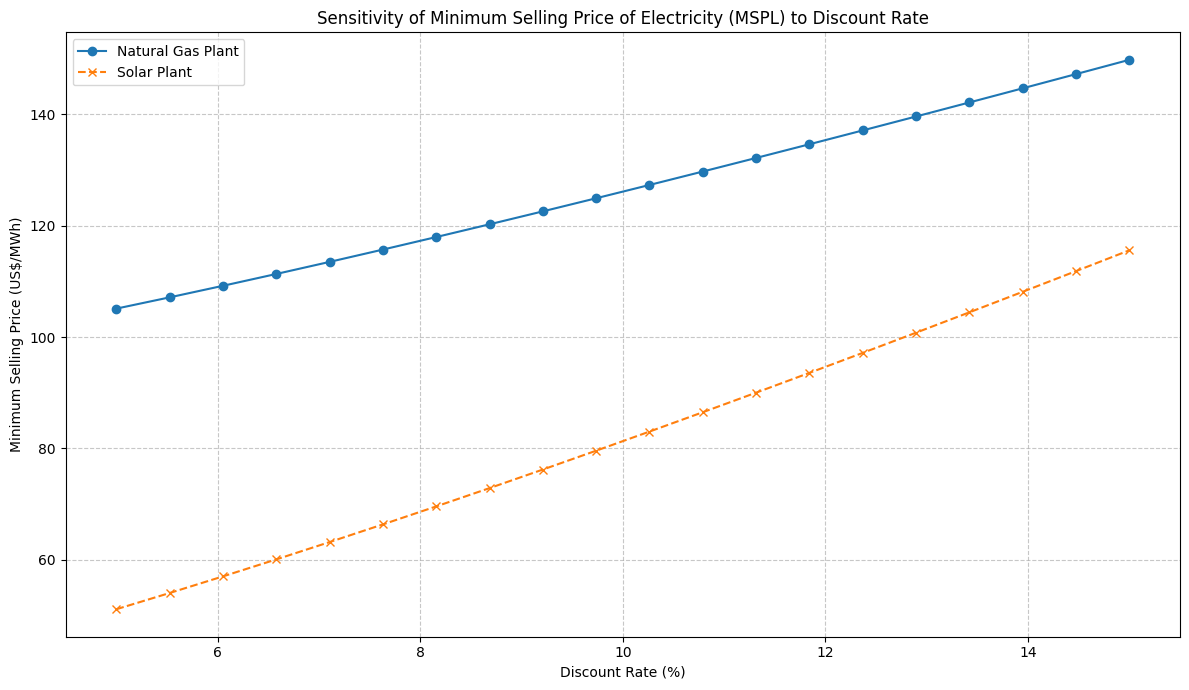

In [ ]:
from scipy.optimize import fsolve

def calculate_mspl_for_discount_rate(new_discount_rate, plant_type):
    # This function is a wrapper around calculate_npv_for_price but uses the new_discount_rate
    # It returns the minimum selling price for the given discount rate

    # Inner function to calculate NPV for a given price and discount rate
    def npv_at_current_rate(price_per_mwh):
        # Retrieve plant-specific parameters (mostly from global scope for simplicity)
        if plant_type == 'gas':
            current_total_investment_cost = total_investment_cost_gas
            current_annual_generation_mwh = annual_generation_gas_mwh
            current_annual_o_m_usd = annual_o_m_gas_usd
            current_annual_fuel_cost_usd = annual_fuel_cost_gas_usd
            current_operational_life_years = operational_life_gas_years
            current_depreciation = depreciation_gas
        elif plant_type == 'solar':
            current_total_investment_cost = total_investment_cost_solar
            current_annual_generation_mwh = annual_generation_solar_mwh
            current_annual_o_m_usd = annual_o_m_solar_usd
            current_annual_fuel_cost_usd = 0 # Solar has no fuel costs
            current_operational_life_years = operational_life_solar_years
            current_depreciation = depreciation_solar
        else:
            raise ValueError("Invalid plant_type. Must be 'gas' or 'solar'.")

        # --- Calculate Annual Cash Flow Components ---
        gross_revenue = price_per_mwh * current_annual_generation_mwh
        net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
        total_annual_costs = current_annual_o_m_usd + current_annual_fuel_cost_usd

        real_profit = net_revenue - total_annual_costs - current_depreciation

        irpj = max(0, tax_ir_base * real_profit)
        csll = max(0, tax_csll * real_profit)
        ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

        cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

        # --- Calculate NPV ---
        npv = -current_total_investment_cost # Initial investment at year 0 (COD)

        for t in range(1, current_operational_life_years + 1):
            npv += cash_flow_t / ((1 + new_discount_rate)**t)
        return npv

    # Retrieve plant-specific parameters for initial guess
    if plant_type == 'gas':
        current_annual_o_m_usd = annual_o_m_gas_usd
        current_annual_fuel_cost_usd = annual_fuel_cost_gas_usd
        current_annual_generation_mwh = annual_generation_gas_mwh
    elif plant_type == 'solar':
        current_annual_o_m_usd = annual_o_m_solar_usd
        current_annual_fuel_cost_usd = 0
        current_annual_generation_mwh = annual_generation_solar_mwh
    else:
        raise ValueError("Invalid plant_type. Must be 'gas' or 'solar'.")

    # Use fsolve to find the price that makes NPV = 0
    initial_guess = (current_annual_o_m_usd + current_annual_fuel_cost_usd) / current_annual_generation_mwh * 2 # Simple heuristic

    # Use fsolve to find the root (price where NPV is zero)
    # The args argument for fsolve is for parameters to npv_at_current_rate if it were passed outside
    # but here npv_at_current_rate is nested and uses outer scope variables.
    return fsolve(npv_at_current_rate, initial_guess)[0]

# Define a range of discount rates to test (e.g., from 5% to 15%)
discount_rates_to_test = np.linspace(0.05, 0.15, 20) # 20 points from 5% to 15%

# Calculate MSPL for each plant across the range of discount rates
mspl_gas_sensitivity = []
mspl_solar_sensitivity = []

for dr in discount_rates_to_test:
    mspl_gas_sensitivity.append(calculate_mspl_for_discount_rate(dr, 'gas'))
    mspl_solar_sensitivity.append(calculate_mspl_for_discount_rate(dr, 'solar'))

# --- Plotting the Sensitivity Analysis ---
plt.figure(figsize=(12, 7))
plt.plot(discount_rates_to_test * 100, mspl_gas_sensitivity, label='Natural Gas Plant', marker='o', linestyle='-')
plt.plot(discount_rates_to_test * 100, mspl_solar_sensitivity, label='Solar Plant', marker='x', linestyle='--')

plt.title('Sensitivity of Minimum Selling Price of Electricity (MSPL) to Discount Rate')
plt.xlabel('Discount Rate (%)')
plt.ylabel('Minimum Selling Price (US$/MWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

,Metric,Natural Gas Plant,Solar Plant
0,LCOE (US$/MWh),102.01,56.98
1,Minimum Selling Price Electricity (US$/MWh),121.64,74.87
2,Minimum Selling Price Capacity (US$/MW/year),"319,663.24",N/A


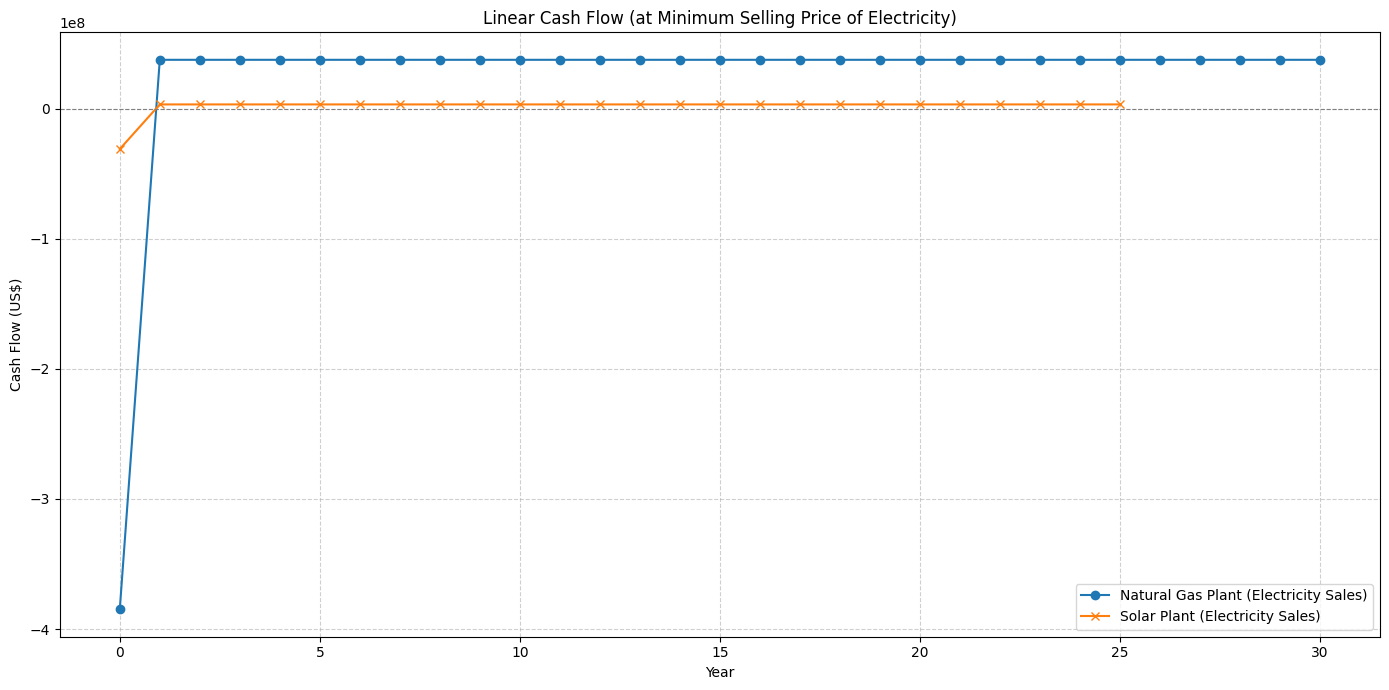

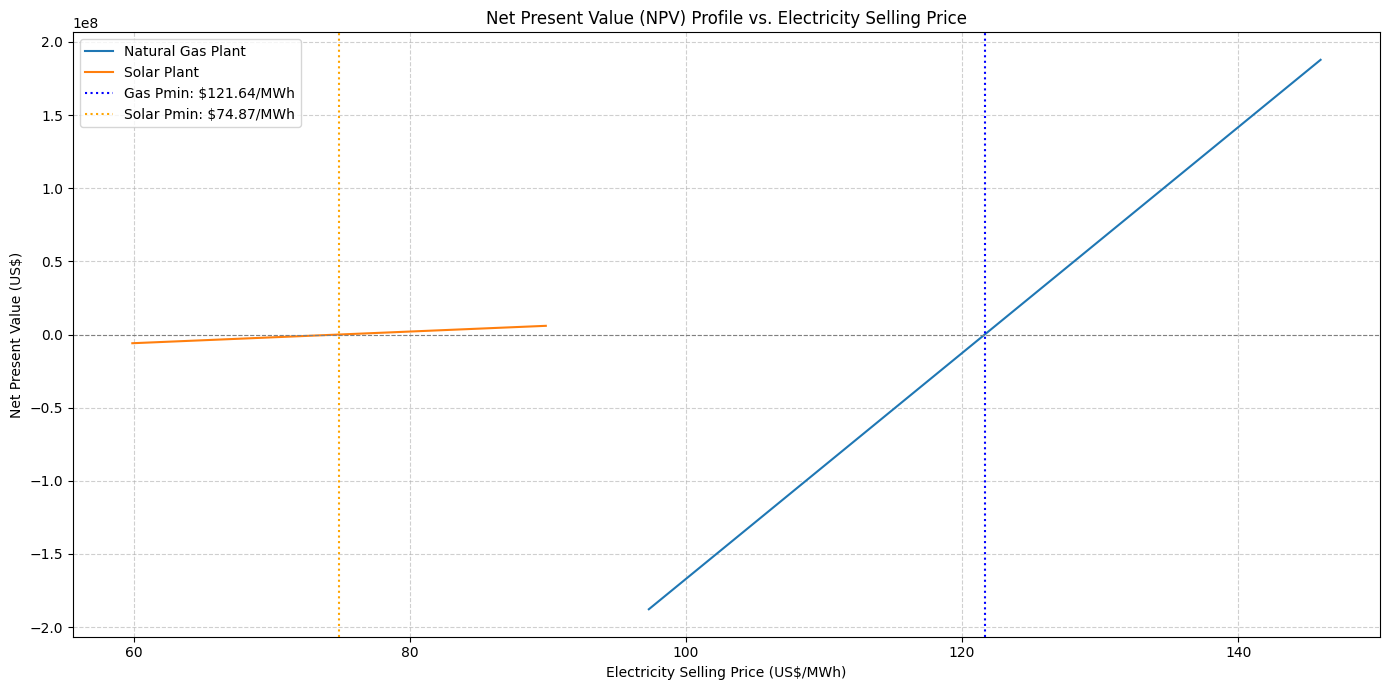

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Summary Table of Results ---
results_data = {
    'Metric': [
        'LCOE (US$/MWh)',
        'Minimum Selling Price Electricity (US$/MWh)',
        'Minimum Selling Price Capacity (US$/MW/year)'
    ],
    'Natural Gas Plant': [
        f"{lcoe_gas_usd_per_mwh:,.2f}",
        f"{min_selling_price_gas:,.2f}",
        f"{min_selling_price_capacity_gas:,.2f}"
    ],
    'Solar Plant': [
        f"{lcoe_solar_usd_per_mwh:,.2f}",
        f"{min_selling_price_solar:,.2f}",
        "N/A" # Not applicable for solar in this problem
    ]
}

df_results = pd.DataFrame(results_data)
display(df_results)

# --- Function to get annual cash flows for plotting ---
def get_annual_cash_flows_for_plot(
    price_per_mwh, plant_type_str,
    operational_life_years, total_investment_cost,
    annual_generation_mwh, annual_o_m_usd, annual_fuel_cost_usd,
    depreciation, total_gross_revenue_taxes_rate, tax_ir_base,
    tax_csll, tax_ir_additional, ir_profit_threshold_annual_usd,
    discount_rate_for_plotting
):
    cash_flows_linear = []
    cash_flows_discounted = []

    # Initial investment at Year 0
    cash_flows_linear.append(-total_investment_cost)
    cash_flows_discounted.append(-total_investment_cost)

    for t in range(1, operational_life_years + 1):
        gross_revenue = price_per_mwh * annual_generation_mwh
        net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
        total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

        real_profit = net_revenue - total_annual_costs - depreciation

        irpj = max(0, tax_ir_base * real_profit)
        csll = max(0, tax_csll * real_profit)
        ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

        # Cash flow for year t
        cf_t_linear = net_revenue - total_annual_costs - irpj - csll - ir_additional
        cash_flows_linear.append(cf_t_linear)
        cash_flows_discounted.append(cf_t_linear / ((1 + discount_rate_for_plotting)**t))

    return cash_flows_linear, cash_flows_discounted

# --- Get Cash Flows for Natural Gas Plant (at min selling price electricity) ---
cf_gas_linear, cf_gas_discounted = get_annual_cash_flows_for_plot(
    min_selling_price_gas, 'gas', operational_life_gas_years,
    total_investment_cost_gas, annual_generation_gas_mwh,
    annual_o_m_gas_usd, annual_fuel_cost_gas_usd, depreciation_gas,
    total_gross_revenue_taxes_rate, tax_ir_base, tax_csll,
    tax_ir_additional, ir_profit_threshold_annual_usd, discount_rate_pvm
)

# --- Get Cash Flows for Solar Plant (at min selling price electricity) ---
cf_solar_linear, cf_solar_discounted = get_annual_cash_flows_for_plot(
    min_selling_price_solar, 'solar', operational_life_solar_years,
    total_investment_cost_solar, annual_generation_solar_mwh,
    annual_o_m_solar_usd, 0, depreciation_solar,
    total_gross_revenue_taxes_rate, tax_ir_base, tax_csll,
    tax_ir_additional, ir_profit_threshold_annual_usd, discount_rate_pvm
)

# --- Plot Linear Cash Flow ---
plt.figure(figsize=(14, 7))
plt.plot(range(operational_life_gas_years + 1), cf_gas_linear, label='Natural Gas Plant (Electricity Sales)', marker='o')
plt.plot(range(operational_life_solar_years + 1), cf_solar_linear, label='Solar Plant (Electricity Sales)', marker='x')
plt.title('Linear Cash Flow (at Minimum Selling Price of Electricity)')
plt.xlabel('Year')
plt.ylabel('Cash Flow (US$)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Discounted Cash Flow (NPV Profile) ---
# Define a range of prices around the minimum selling price for plotting NPV profile
price_range_gas = np.linspace(min_selling_price_gas * 0.8, min_selling_price_gas * 1.2, 50)
npv_profile_gas = [calculate_npv_for_price(p, 'gas') for p in price_range_gas]

price_range_solar = np.linspace(min_selling_price_solar * 0.8, min_selling_price_solar * 1.2, 50)
npv_profile_solar = [calculate_npv_for_price(p, 'solar') for p in price_range_solar]

plt.figure(figsize=(14, 7))
plt.plot(price_range_gas, npv_profile_gas, label='Natural Gas Plant')
plt.plot(price_range_solar, npv_profile_solar, label='Solar Plant')

# Mark the minimum selling price where NPV is zero
plt.axvline(min_selling_price_gas, color='blue', linestyle=':', label=f'Gas Pmin: ${min_selling_price_gas:,.2f}/MWh')
plt.axvline(min_selling_price_solar, color='orange', linestyle=':', label=f'Solar Pmin: ${min_selling_price_solar:,.2f}/MWh')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title('Net Present Value (NPV) Profile vs. Electricity Selling Price')
plt.xlabel('Electricity Selling Price (US$/MWh)')
plt.ylabel('Net Present Value (US$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



---





---

# **Questão2 - Economia de Energia II**

# Task
Generate a comprehensive academic report in Portuguese evaluating the economic viability of natural gas and solar power generation projects. The report should include detailed methodology sections for investment cost calculation, annual generation and operational costs, Levelized Cost of Electricity (LCOE), minimum selling price of electricity (Pmin), and minimum selling price for capacity. It must also present a summary of results, visualize cash flows, perform a sensitivity analysis on the minimum selling price versus discount rate, and conclude with key findings and suggested references.

## Traduzir e Formatar Introdução

### Subtask:
Traduzir as seções introdutórias e a definição de parâmetros para o português, formatando-as como a parte inicial de um relatório acadêmico, incluindo a justificativa para a taxa de desconto inicial.


```markdown
# **Atividade Individual de Economia de Energia II**

- Letícia Sampaio Drummond Valladares RA:298985
- Professor: Arnaldo Walter

Junho de 2026

---

## Avaliação Econômica de Projetos de Geração de Energia

Esta seção aborda a avaliação econômica de duas alternativas de investimento em geração de energia: uma usina termelétrica a gás natural (480MW) e uma usina solar (25MW). O objetivo é calcular o preço mínimo de venda da eletricidade, o Custo Nivelado de Eletricidade (LCOE) e o preço mínimo de venda por capacidade para a usina de gás natural.

### 1. Definição de Parâmetros

Primeiramente, vamos definir todos os parâmetros de entrada fornecidos na descrição do problema, incluindo a taxa de desconto escolhida. O problema estabelece que a taxa de desconto deve ser justificada; para investimentos privados no setor de energia, as taxas geralmente variam de 8% a 15%, dependendo do risco. Dada a ausência de perfis de risco específicos, uma taxa de desconto de **10%** é escolhida como um benchmark razoável e comumente utilizado para projetos com risco moderado, equilibrando os retornos do investidor e a viabilidade do projeto.

**Premissas:**
*   **Fator de Capacidade (FC anual %)**: Interpretado como o fator de capacidade anual (ou fator de carga) para ambas as tecnologias, representando a produção real ao longo de um período como uma porcentagem da produção máxima possível.
*   **Unidades Monetárias**: Todos os cálculos serão realizados em **USD**, uma vez que todos os dados de custo fornecidos estão em US$. Se uma taxa de câmbio fosse fornecida, conversões para limites específicos em BRL (como o limite de lucro para IR) seriam aplicadas.
*   **Horas por Ano**: Assumidas como 8760 horas (24 horas * 365 dias).
*   **Inflação**: Não especificada, portanto, todos os custos e receitas são assumidos em termos reais (dólares constantes), consistente com uma taxa de desconto real.
```

## Traduzir e Detalhar Metodologia - Custo de Investimento

### Subtask:
Traduzir a seção de cálculo do custo de investimento para o português, detalhando a metodologia (incluindo a capitalização durante a construção) em linguagem acadêmica, explicando como o custo de investimento na Data de Operação Comercial (DOC) é derivado.


```markdown
### 2. Cálculo do Custo de Investimento

Esta seção detalha o cálculo do custo total de investimento para as usinas de gás natural e solar. O cálculo considera os **custos "overnight"** (custos de capital sem considerar juros durante a construção), a capacidade instalada e o cronograma de construção. Para refletir o **valor do dinheiro no tempo** durante a fase de construção, aplica-se a taxa de desconto apropriada aos desembolsos de capital.

Adotaremos a metodologia de calcular o **valor presente de todas as despesas de construção na Data de Operação Comercial (DOC)**, que corresponde ao 'Ano 0' nas frações de construção fornecidas. Essa abordagem é consistente com a prática de financiamento de projetos, onde o investimento total é avaliado no momento em que a usina se torna operacional.

Para isso, os gastos de construção incorridos antes da DOC (por exemplo, no 'Ano -2' e 'Ano -1') são **capitalizados** (compostos) até a DOC, utilizando a taxa de desconto. Isso significa que o valor desses desembolsos passados é ajustado para seu equivalente futuro na DOC, refletindo o custo de oportunidade do capital ao longo do período de construção.
```

```markdown
Inicialmente, calcula-se o custo "overnight" total para cada usina. Este custo representa o investimento de capital sem a inclusão de juros durante o per\u00edodo de constru\u00e7\u00e3o e \u00e9 determinado multiplicando-se a capacidade instalada (em kW) pelo custo "overnight" por kW. O c\u00f3digo abaixo ilustra este c\u00e1lculo para ambas as tecnologias:

```python
# Total Overnight Costs
total_overnight_costs_gas = capacity_gas_mw * 1000 * overnight_costs_gas_usd_per_kw
total_overnight_costs_solar = capacity_solar_mw * 1000 * overnight_costs_solar_usd_per_kw

print(f"Total Overnight Costs for Natural Gas Plant: US$ {total_overnight_costs_gas:,.2f}")
print(f"Total Overnight Costs for Solar Plant: US$ {total_overnight_costs_solar:,.2f}")
```

Em seguida, para obter o **Custo Total de Investimento na Data de Operações Comercial (DOC)**, os custos "overnight" são distribuídos pelos anos de construção  e de acordo com as fra\u00e7\u00f5es fornecidas. Cada parcela do investimento \u00e9 ent\u00e3o capitalizada at\u00e9 a DOC, utilizando a taxa de desconto definida. Isso assegura que o valor do dinheiro no tempo seja corretamente incorporado. A l\u00f3gica para essa capitaliza\u00e7\u00e3o \u00e9 apresentada no trecho de c\u00f3digo a seguir:

```python
# C\u00e1lculo do custo total de investimento incluindo financiamento durante a constru\u00e7\u00e3o
construction_pv_gas = 0
for year_str, fraction in construction_fractions_gas.items():
    year_offset = int(year_str.split(' ')[1])
    years_to_compound = -year_offset # Compounding for 'n' years forward to COD
    construction_pv_gas += total_overnight_costs_gas * fraction * ((1 + discount_rate)**years_to_compound)

construction_pv_solar = 0
for year_str, fraction in construction_fractions_solar.items():
    year_offset = int(year_str.split(' ')[1])
    years_to_compound = -year_offset
    construction_pv_solar += total_overnight_costs_solar * fraction * ((1 + discount_rate)**years_to_compound)

total_investment_cost_gas = construction_pv_gas
total_investment_cost_solar = construction_pv_solar

print(f"Total Investment Cost (at COD) for Natural Gas Plant: US$ {total_investment_cost_gas:,.2f}")
print(f"Total Investment Cost (at COD) for Solar Plant: US$ {total_investment_cost_solar:,.2f}")
```


## Traduzir e Detalhar Metodologia - Geração Anual e Custos

### Subtask:
Traduzir a seção de cálculo da geração anual de eletricidade e custos operacionais e de combustível para o português, detalhando a metodologia utilizada para cada componente, incluindo a conversão de MWh para GJ e o uso da eficiência.


```markdown
### 3. Geração Anual de Eletricidade e Custos Operacionais

Esta seção detalha a metodologia utilizada para calcular a geração anual de eletricidade e os custos operacionais (O&M) e de combustível para as usinas de gás natural e solar. Esses cálculos são fundamentais para a avaliação econômica subsequente, incluindo o Custo Nivelado de Eletricidade (LCOE).

**Cálculo da Geração Anual de Eletricidade:**
A geração anual de eletricidade para cada usina é determinada multiplicando-se sua capacidade instalada (em MW) pelo fator de capacidade anual (FC) e pelo número total de horas em um ano. Este cálculo representa a quantidade total de energia que a usina pode produzir em um ano, considerando sua disponibilidade e eficiência operacional:

$$ Geração_{anual} (MWh) = Capacidade (MW) \times FatorCapacidade \times HorasAno $$

**Cálculo dos Custos Anuais de O&M (Operação e Manutenção):**
Os custos anuais de O&M são calculados multiplicando-se o custo de O&M por megawatt-hora (US$/MWh) pela geração anual de eletricidade da usina. Este valor engloba todas as despesas relacionadas à operação e manutenção da usina, excluindo o custo do combustível:

$$ O\&M_{anual} (US$) = O\&M_{MWh} (US$/MWh) \times Geração_{anual} (MWh) $$

**Cálculo dos Custos Anuais de Combustível (Apenas para Usina a Gás Natural):**
Para a usina a gás natural, o cálculo dos custos de combustível é mais complexo devido à necessidade de considerar a eficiência da usina e a unidade de medida do custo do combustível. A metodologia envolve as seguintes etapas:

1.  **Conversão da Geração para Unidades de Energia Térmica:** A geração anual de eletricidade (MWh) é convertida para Gigajoules (GJ) usando o fator de conversão de 3.6 GJ por MWh.

    $$ Geração_{anual} (GJ) = Geração_{anual} (MWh) \times 3.6 (GJ/MWh) $$

2.  **Cálculo do Combustível Necessário:** O total de energia térmica necessária (em GJ) é então dividido pela eficiência elétrica da usina para determinar a quantidade de combustível bruto (em GJ) que precisa ser consumido para produzir a eletricidade desejada.

    $$ Combustível_{necessário} (GJ) = Geração_{anual} (GJ) / Eficiência_{elétrica} $$

3.  **Cálculo do Custo Anual do Combustível:** Finalmente, o custo anual do combustível é obtido multiplicando-se o combustível necessário (em GJ) pelo custo do combustível por Gigajoule (US$/GJ).

    $$ CustoCombustível_{anual} (US$) = Combustível_{necessário} (GJ) \times CustoCombustível_{GJ} (US$/GJ) $$

A usina solar, por ser uma fonte renovável, não incorre em custos de combustível.
```

**Reasoning**:
Generate a code block to calculate the annual electricity generation, annual O&M costs, and annual fuel costs (for the natural gas plant) based on the defined parameters and display the results, matching the description.



In [ ]:
# --- Annual Electricity Generation ---
# Annual generation (MWh) = Capacity (MW) * Capacity Factor * Hours per Year
annual_generation_gas_mwh = capacity_gas_mw * capacity_factor_gas_percent * hours_per_year
annual_generation_solar_mwh = capacity_solar_mw * capacity_factor_solar_percent * hours_per_year

print(f"Annual Electricity Generation for Natural Gas Plant: {annual_generation_gas_mwh:,.2f} MWh")
print(f"Annual Electricity Generation for Solar Plant: {annual_generation_solar_mwh:,.2f} MWh")

# --- Annual O&M Costs ---
# Annual O&M (USD) = O&M per MWh * Annual Generation (MWh)
annual_o_m_gas_usd = o_m_gas_usd_per_mwh * annual_generation_gas_mwh
annual_o_m_solar_usd = o_m_solar_usd_per_mwh * annual_generation_solar_mwh

print(f"Annual O&M Costs for Natural Gas Plant: US$ {annual_o_m_gas_usd:,.2f}")
print(f"Annual O&M Costs for Solar Plant: US$ {annual_o_m_solar_usd:,.2f}")

# --- Annual Fuel Costs (Natural Gas Plant only) ---
# Energy content of natural gas is typically in GJ. Efficiency is a key factor.
# Fuel consumption = (Annual Generation MWh * 3.6 GJ/MWh) / Efficiency
# Annual Fuel Cost = Fuel Consumption * Fuel Cost per GJ

# Convert MWh to GJ for fuel calculation (1 MWh = 3.6 GJ)
annual_generation_gas_gj = annual_generation_gas_mwh * 3.6

# Fuel required in GJ, considering efficiency
fuel_required_gas_gj = annual_generation_gas_gj / efficiency_gas_percent

# Annual Fuel Cost
annual_fuel_cost_gas_usd = fuel_required_gas_gj * fuel_cost_gas_usd_per_gj

print(f"Annual Fuel Costs for Natural Gas Plant: US$ {annual_fuel_cost_gas_usd:,.2f}")

## Traduzir e Detalhar Metodologia - Cálculo do LCOE

### Subtask:
Traduzir a seção de cálculo do Custo Nivelado de Energia (LCOE), fornecendo a fórmula e a explicação em português, destacando os componentes da soma e o uso do Fator de Valor Presente do Anuidade (PVIFA).


```markdown
### 4. Cálculo do Custo Nivelado de Eletricidade (LCOE)

O Custo Nivelado de Eletricidade (LCOE) representa o custo médio por unidade de eletricidade gerada que seria necessário para cobrir os custos de construção e operação de uma usina ao longo de sua vida útil financeira e ciclo de operação. É uma métrica amplamente utilizada para comparar a competitividade de diferentes tecnologias de geração de energia.

A fórmula geral para o LCOE (em US$/MWh) é:

$$ LCOE = \frac{\sum_{t=1}^{n} \frac{I_t + O\&M_t + F_t}{(1+r)^t}}{\sum_{t=1}^{n} \frac{E_t}{(1+r)^t}} $$

Onde:
*   $I_t$: Despesas de investimento no ano $t$
*   $O\&M_t$: Despesas de operação e manutenção no ano $t$
*   $F_t$: Despesas com combustível no ano $t$
*   $E_t$: Eletricidade gerada no ano $t$
*   $r$: Taxa de desconto
*   $n$: Vida operacional da usina

Considerando que assumimos custos anuais de O&M e combustível constantes, e que o investimento total é capitalizado para o Ano 0 (Data de Operação Comercial - DOC), a fórmula se simplifica. Os termos de somatório no numerador e denominador representam o valor presente de uma série uniforme de pagamentos/recebimentos, que pode ser simplificado usando o **Fator de Valor Presente do Anuidade (PVIFA)**. O PVIFA permite calcular o valor presente de uma série de fluxos de caixa iguais que ocorrem em intervalos regulares.

A fórmula do PVIFA é:

$$ PVIFA = \frac{1 - (1+r)^{-n}}{r} $$

Assim, o LCOE pode ser calculado de forma simplificada como:

$$ LCOE = \frac{Custo Total de Investimento + (O\&M Anual + Combustível Anual) \times PVIFA}{Geração Anual \times PVIFA} $$

Esta simplificação é válida pois tanto os custos operacionais anuais quanto a geração anual são constantes ao longo da vida operacional, permitindo que a soma dos valores presentes desses fluxos seja calculada de forma eficiente via PVIFA.

**Reasoning**:
I will generate the Python code to calculate the LCOE for both plants, implementing the PVIFA-based simplified formula previously detailed.



In [ ]:
import numpy as np

# Function to calculate Present Value Interest Factor of an Annuity (PVIFA)
def calculate_pvifa(rate, periods):
    if rate == 0:
        return periods
    return (1 - (1 + rate)**(-periods)) / rate

# --- LCOE for Natural Gas Plant ---
pvifa_gas = calculate_pvifa(discount_rate, operational_life_gas_years)

present_value_opex_gas = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) * pvifa_gas
present_value_generation_gas = annual_generation_gas_mwh * pvifa_gas

lcoe_gas_usd_per_mwh = (total_investment_cost_gas + present_value_opex_gas) / present_value_generation_gas

print(f"Levelized Cost of Electricity (LCOE) for Natural Gas Plant: US$ {lcoe_gas_usd_per_mwh:,.2f}/MWh")

# --- LCOE for Solar Plant ---
pvifa_solar = calculate_pvifa(discount_rate, operational_life_solar_years)

# Solar plant has no fuel costs
present_value_opex_solar = annual_o_m_solar_usd * pvifa_solar
present_value_generation_solar = annual_generation_solar_mwh * pvifa_solar

lcoe_solar_usd_per_mwh = (total_investment_cost_solar + present_value_opex_solar) / present_value_generation_solar

print(f"Levelized Cost of Electricity (LCOE) for Solar Plant: US$ {lcoe_solar_usd_per_mwh:,.2f}/MWh")

## Traduzir e Detalhar Metodologia - Preço Mínimo de Venda de Eletricidade (Pmin)

### Subtask:
Traduzir a seção de cálculo do Preço Mínimo de Venda de Eletricidade (Pmin), explicando o modelo de fluxo de caixa, a depreciação linear, a estrutura tributária (incluindo IR Adicional) e o papel da função 'fsolve' para encontrar o preço que resulta em VPL zero.


```markdown
### 5. Preço Mínimo de Venda de Eletricidade (Pmin)

Para determinar o preço mínimo de venda da eletricidade (Pmin), buscamos o preço ($P$) que torna o Valor Presente Líquido (VPL) do projeto igual a zero ao longo de sua vida operacional. Este cálculo incorpora depreciação, custos operacionais e de combustível anuais, bem como a estrutura tributária brasileira detalhada, incluindo o Imposto de Renda Adicional.

**Componentes Chave do Modelo de Fluxo de Caixa para o Pmin:**

1.  **Geração Anual de Eletricidade ($E_{anual}$)**: A produção de energia em MWh/ano, já calculada na seção anterior.

2.  **Depreciação**: A depreciação é calculada de forma linear com base no custo de capital inicial (`CAPEX Overnight`) e distribuída uniformemente ao longo da vida operacional do projeto. Isso permite deduzir uma parcela do investimento anualmente para fins fiscais.
    $$ Depreciação_{anual} = CAPEX_{Overnight} / Vida_{Operacional} $$

3.  **Receita Bruta ($Receita Bruta$)**: É o valor total da venda de eletricidade, calculado como o preço de venda ($P$) multiplicado pela geração anual de eletricidade.
    $$ Receita Bruta = P \times E_{anual} $$

4.  **Receita Líquida ($Receita Líquida$)**: A receita bruta é ajustada pela dedução dos impostos sobre a receita bruta, que incluem PIS (Programa de Integração Social), COFINS (Contribuição para o Financiamento da Seguridade Social) e TFSEE (Taxa de Fiscalização de Serviços de Energia Elétrica). Estes são percentuais aplicados diretamente sobre a receita bruta.
    $$ Receita Líquida = Receita Bruta \times (1 - (Taxa PIS + Taxa COFINS + Taxa TFSEE)) $$

5.  **Custos Anuais ($Custos$)**: Englobam os custos anuais de Operação e Manutenção (O&M) e, para a usina a gás natural, os custos anuais de combustível. Para a usina solar, os custos de combustível são zero.
    $$ Custos_{Anuais} = O\&M_{Anual} + Combustível_{Anual} $$

6.  **Lucro Real ($Lucro Real$)**: É o lucro antes dos impostos sobre o lucro, obtido pela dedução dos custos anuais e da depreciação da receita líquida.
    $$ Lucro Real = Receita Líquida - Custos_{Anuais} - Depreciação_{Anual} $$

7.  **Impostos sobre o Lucro**: Sobre o lucro real são aplicados:
    *   **IRPJ (Imposto de Renda de Pessoa Jurídica)**: Uma taxa base de 15% sobre o lucro real.
    *   **CSLL (Contribuição Social sobre o Lucro Líquido)**: Uma taxa de 9% sobre o lucro real.
    *   **IR Adicional (Imposto de Renda Adicional)**: Uma taxa adicional de 10% aplicada sobre a parcela do lucro real que excede um determinado limite anual (US$240,000, equivalente a US$20,000 mensais). Apenas a diferença acima do limite é tributada a essa alíquota extra.
    É importante notar que esses impostos são calculados apenas se o Lucro Real for positivo.

8.  **Fluxo de Caixa ($FC_t$)**: O fluxo de caixa anual é determinado pela receita líquida, subtraindo-se os custos anuais e os impostos sobre o lucro. Este fluxo é calculado para cada ano da vida operacional do projeto.
    $$ FC_t = Receita Líquida - Custos_{Anuais} - IRPJ - CSLL - IR_{Adicional} $$

**Critério de VPL Zero e Uso da Função `fsolve`:**

O objetivo é encontrar o preço de venda da eletricidade ($P$) que resulta em um Valor Presente Líquido (VPL) de zero para o projeto. O VPL é a soma dos fluxos de caixa anuais descontados, subtraindo-se o investimento inicial.

$$ VPL = -Investimento_{Inicial} + \sum_{t=1}^{n} \frac{FC_t}{(1+r)^t} $$

A função `fsolve` da biblioteca `scipy.optimize` é uma ferramenta numérica utilizada para encontrar as raízes (zeros) de uma função não linear. Neste contexto, definimos uma função que calcula o VPL para um dado preço de eletricidade. `fsolve` então itera, ajustando o preço, até encontrar o valor para o qual o VPL da função é aproximadamente zero, determinando assim o Pmin.

Primeiramente, atualizamos a taxa de desconto para 9% para este cálculo específico e definimos a depreciação anual com base nos custos overnight. O código a seguir calcula esses valores e a taxa total de impostos sobre a receita bruta.

```python
from scipy.optimize import fsolve

# Update discount rate as per user's instruction for this specific calculation
discount_rate_pvm = 0.09 # 9% per year

# --- Calculate Annual Depreciation ---
# Depreciation is based on Overnight CAPEX / Operational Life
depreciation_gas = total_overnight_costs_gas / operational_life_gas_years
depreciation_solar = total_overnight_costs_solar / operational_life_solar_years

print(f"Annual Depreciation for Natural Gas Plant: US$ {depreciation_gas:,.2f}")
print(f"Annual Depreciation for Solar Plant: US$ {depreciation_solar:,.2f}")

# Combine the gross revenue taxes
total_gross_revenue_taxes_rate = tax_confins + tax_pis + tax_tfsee

# Annual threshold for additional IR (monthly * 12)
ir_profit_threshold_annual_usd = ir_profit_threshold_monthly_usd * 12

def calculate_npv_for_price(price_per_mwh, plant_type):
    # Retrieve plant-specific parameters
    if plant_type == 'gas':
        total_investment_cost = total_investment_cost_gas
        annual_generation_mwh = annual_generation_gas_mwh
        annual_o_m_usd = annual_o_m_gas_usd
        annual_fuel_cost_usd = annual_fuel_cost_gas_usd
        operational_life_years = operational_life_gas_years
        depreciation = depreciation_gas
    elif plant_type == 'solar':
        total_investment_cost = total_investment_cost_solar
        annual_generation_mwh = annual_generation_solar_mwh
        annual_o_m_usd = annual_o_m_solar_usd
        annual_fuel_cost_usd = 0 # Solar has no fuel costs
        operational_life_years = operational_life_solar_years
        depreciation = depreciation_solar
    else:
        raise ValueError("Invalid plant_type. Must be 'gas' or 'solar'.")

    # --- Calculate Annual Cash Flow Components ---
    gross_revenue = price_per_mwh * annual_generation_mwh
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price (P) that makes NPV = 0 ---
# We need an initial guess for fsolve. A good starting point could be the LCOE or higher.
initial_guess_gas = lcoe_gas_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit
initial_guess_solar = lcoe_solar_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit

# Use fsolve to find the root (price where NPV is zero)
min_selling_price_gas = fsolve(calculate_npv_for_price, initial_guess_gas, args=('gas',))[0]
min_selling_price_solar = fsolve(calculate_npv_for_price, initial_guess_solar, args=('solar',))[0]

print(f"\nMinimum Selling Price for Natural Gas Plant: US$ {min_selling_price_gas:,.2f}/MWh")
print(f"Minimum Selling Price for Solar Plant: US$ {min_selling_price_solar:,.2f}/MWh")
```


## Traduzir e Detalhar Metodologia - Preço Mínimo de Venda por Capacidade

### Subtask:
Traduzir a seção de cálculo do preço mínimo de venda por capacidade, explicando a adaptação do modelo de fluxo de caixa para receitas de capacidade e a metodologia para determinar o preço mínimo por MW/ano.


```markdown
### 6. Preço Mínimo de Venda por Capacidade (Usina a Gás Natural)

Para a usina termelétrica a gás natural, o problema solicita o cálculo do preço mínimo pelo qual sua capacidade de geração deve ser oferecida. Neste cenário, a receita da usina adviria da venda de sua capacidade instalada (MW) por um preço específico por unidade de capacidade (por exemplo, US$/MW/ano), em vez de ser baseada na eletricidade efetivamente gerada. Isso significa que o fluxo de receita seria independente da produção de energia, embora todos os custos operacionais (O&M e combustível) e impostos ainda se apliquem.

Para determinar este preço, novamente utilizaremos o critério de **Valor Presente Líquido (VPL) igual a zero**. A principal modificação no modelo de fluxo de caixa será a forma como a receita bruta é calculada:

$$ Receita Bruta = Preço_{Capacidade} (US$/MW/ano) \times Capacidade_{Instalada} (MW) $$

Os demais componentes de custo e as deduções tributárias serão aplicados conforme o modelo anterior, mantendo-se a taxa de desconto de **9%** (discount_rate_pvm) utilizada para o cálculo do Pmin. O objetivo é encontrar o valor do `Preço_Capacidade` que zere o VPL do projeto, considerando sua vida operacional.

O código Python a seguir implementa essa metodologia, utilizando a função `fsolve` para encontrar o preço mínimo de venda por MW/ano.
```

**Reasoning**:
The previous step explained the methodology for calculating the minimum selling price for capacity. This step will provide the Python code implementation of that methodology, including the `calculate_npv_for_capacity_price` function and the use of `fsolve` to determine the minimum selling price for capacity.



In [ ]:
from scipy.optimize import fsolve

def calculate_npv_for_capacity_price(capacity_price_per_mw_year):
    # Parameters for Natural Gas Plant
    total_investment_cost = total_investment_cost_gas
    capacity_mw = capacity_gas_mw
    annual_o_m_usd = annual_o_m_gas_usd
    annual_fuel_cost_usd = annual_fuel_cost_gas_usd
    operational_life_years = operational_life_gas_years
    depreciation = depreciation_gas

    # --- Calculate Annual Cash Flow Components ---
    # Gross revenue now comes from capacity sales
    gross_revenue = capacity_price_per_mw_year * capacity_mw
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price for Capacity (P_capacity) that makes NPV = 0 ---
# We need an initial guess for fsolve. Let's estimate based on total annual costs / capacity.
estimated_annual_operating_cost_per_mw = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) / capacity_gas_mw
initial_guess_capacity_price = (estimated_annual_operating_cost_per_mw + (total_investment_cost_gas / operational_life_gas_years / capacity_gas_mw)) * 2 # heuristic guess

min_selling_price_capacity_gas = fsolve(calculate_npv_for_capacity_price, initial_guess_capacity_price)[0]

print(f"\nMinimum Selling Price for Capacity for Natural Gas Plant: US$ {min_selling_price_capacity_gas:,.2f}/MW/year")


## Traduzir e Apresentar Resultados - Tabela Resumo e Visualizações

### Subtask:
Traduzir o resumo dos resultados, apresentar a tabela `df_results` em português e interpretar os gráficos de fluxo de caixa linear e perfil de VPL, discutindo os principais insights para cada projeto.


**Reasoning**:
Translating the existing `df_results` DataFrame to Portuguese, including column names and metric labels, and then displaying it to fulfill the first two instructions of the subtask.



In [ ]:
df_results_translated = df_results.rename(columns={
    'Metric': 'Métrica',
    'Natural Gas Plant': 'Usina a Gás Natural',
    'Solar Plant': 'Usina Solar'
})

df_results_translated.loc[df_results_translated['Métrica'] == 'LCOE (US$/MWh)', 'Métrica'] = 'Custo Nivelado de Eletricidade (US$/MWh)'
df_results_translated.loc[df_results_translated['Métrica'] == 'Minimum Selling Price Electricity (US$/MWh)', 'Métrica'] = 'Preço Mínimo de Venda de Eletricidade (US$/MWh)'
df_results_translated.loc[df_results_translated['Métrica'] == 'Minimum Selling Price Capacity (US$/MW/year)', 'Métrica'] = 'Preço Mínimo de Venda por Capacidade (US$/MW/ano)'

display(df_results_translated)

```markdown
### Análise dos Gráficos de Fluxo de Caixa e Perfil de VPL

#### Fluxo de Caixa Linear (a Preço Mínimo de Venda de Eletricidade)

O gráfico de Fluxo de Caixa Linear ilustra os fluxos de caixa anuais não descontados para cada projeto ao longo de sua vida operacional, considerando o preço mínimo de venda de eletricidade (Pmin) que zera o VPL.

*   **Usina a Gás Natural:** Após o investimento inicial (representado pelo ponto negativo no ano 0), o fluxo de caixa anual se estabiliza em um valor constante e positivo. Isso indica que, com o preço de venda de US$ 121,64/MWh, a usina a gás natural gera um excedente de caixa consistente a cada ano de operação, cobrindo todos os custos operacionais, impostos e a parcela proporcional da depreciação.
*   **Usina Solar:** Similarmente, a usina solar, operando a um preço de venda de US$ 74,87/MWh, também exibe um fluxo de caixa anual positivo e constante após o ano de investimento inicial. O valor absoluto do fluxo de caixa positivo para a usina solar é menor que o da usina a gás natural, o que é esperado dada sua menor capacidade e, consequentemente, menor volume de geração e custos totais.

Ambos os gráficos demonstram que, ao Pmin, os projetos conseguem cobrir seus custos e gerar valor econômico nominal a cada ano, embora o VPL total seja zero quando os fluxos são descontados.

#### Perfil de VPL vs. Preço de Venda de Eletricidade

O gráfico de Perfil de VPL mostra a relação entre o VPL do projeto e diferentes preços de venda da eletricidade. A interseção de cada curva com o eixo X (VPL = 0) representa o Preço Mínimo de Venda (Pmin) calculado para cada tecnologia.

*   **Usina a Gás Natural:** A curva da usina a gás natural intercepta o eixo X em aproximadamente US$ 121,64/MWh. A inclinação da curva indica a sensibilidade do VPL a variações no preço de venda. Um preço ligeiramente acima do Pmin resultaria em um VPL positivo, tornando o projeto atrativo para investidores.
*   **Usina Solar:** A curva da usina solar intercepta o eixo X em aproximadamente US$ 74,87/MWh, confirmando o menor Pmin em comparação com a usina a gás. A inclinação desta curva também é positiva, mostrando que o VPL aumenta com o aumento do preço de venda. A menor dispersão dos preços em torno do Pmin para a solar, em comparação com a gás, pode indicar uma sensibilidade ligeiramente diferente do VPL ao preço de venda, embora ambos demonstrem a relação fundamental de que o VPL cresce com o preço de venda.

**Insights Principais:**

1.  **Competitividade:** A usina solar apresenta um Pmin significativamente menor (US$ 74,87/MWh) do que a usina a gás natural (US$ 121,64/MWh), o que a torna mais competitiva em termos de custo de energia gerada. Isso está em linha com o LCOE mais baixo da tecnologia solar.
2.  **Viabilidade Econômica:** Ambos os projetos são economicamente viáveis nos seus respectivos Preços Mínimos de Venda, no sentido de que cobrem todos os custos (incluindo o custo de capital através do desconto) ao longo de sua vida útil. Qualquer preço de venda superior ao Pmin geraria um VPL positivo, o que é o objetivo de investimentos privados.
3.  **Sensibilidade ao Preço:** O gráfico do perfil de VPL é crucial para entender a robustez dos projetos a diferentes cenários de preços de mercado. Um projeto com uma curva mais íngreme é mais sensível a variações de preço, enquanto um projeto com uma curva mais suave pode ser mais resiliente a flutuações de mercado.
```

## Traduzir e Apresentar Resultados - Análise de Sensibilidade

### Subtask:
Traduzir a seção de análise de sensibilidade e interpretar o gráfico de MSPL versus Taxa de Desconto, explicando como a variação na taxa de desconto afeta o preço mínimo de venda para ambas as tecnologias.


```markdown
### 8. Análise de Sensibilidade: Preço Mínimo de Venda vs. Taxa de Desconto

Esta seção apresenta uma análise de sensibilidade para entender como o Preço Mínimo de Venda de Eletricidade (MSPL) para as usinas de gás natural e solar se altera com variações na taxa de desconto. Uma gama de taxas de desconto foi testada, e o MSPL correspondente foi calculado e plotado.

#### Interpretação do Gráfico de Sensibilidade (MSPL vs. Taxa de Desconto)

O gráfico "Sensitivity of Minimum Selling Price of Electricity (MSPL) to Discount Rate" ilustra como o preço mínimo de venda de eletricidade, que garante um VPL zero, reage a diferentes taxas de desconto para as duas tecnologias.

*   **Usina a Gás Natural:** A curva da usina a gás natural mostra que, à medida que a taxa de desconto aumenta, o MSPL também aumenta de forma acentuada. Isso ocorre porque a usina a gás natural possui um investimento inicial (CAPEX) e custos de combustível substanciais. Com taxas de desconto mais altas, o valor presente dos fluxos de caixa futuros diminui mais drasticamente, exigindo um preço de venda de eletricidade mais elevado para compensar o custo de capital e garantir a atratividade do projeto.

*   **Usina Solar:** A usina solar também apresenta uma relação direta entre a taxa de desconto e o MSPL, ou seja, um aumento na taxa de desconto resulta em um MSPL mais alto. No entanto, a inclinação da curva da usina solar é visivelmente menor em comparação com a da usina a gás natural. Isso sugere que o MSPL da usina solar é menos sensível a variações na taxa de desconto. A menor sensibilidade pode ser atribuída à sua estrutura de custos, que é mais intensiva em CAPEX (investimento inicial) e tem custos operacionais (O&M) e de combustível (zero) relativamente mais baixos ao longo da vida útil. Embora um CAPEX elevado seja impactado por altas taxas de desconto, a ausência de custos de combustível e O&M mais previsíveis tornam-na mais resiliente do que uma usina a gás.

**Conclusões da Análise de Sensibilidade:**

1.  **Impacto Universal:** Ambas as tecnologias são impactadas negativamente por taxas de desconto crescentes, pois um custo de capital maior exige um preço de venda mais alto para manter a viabilidade do projeto.
2.  **Diferença na Sensibilidade:** A usina a gás natural é consideravelmente mais sensível às variações da taxa de desconto do que a usina solar. Isso implica que projetos a gás natural podem ser mais arriscados em ambientes de alta incerteza sobre o custo de capital ou em mercados onde as taxas de juros são voláteis.
3.  **Implicações de Investimento:** Para investidores que buscam estabilidade e menor risco em cenários de taxas de juros variáveis, a tecnologia solar pode apresentar uma vantagem, dado que seu MSPL flutua menos com as mudanças na taxa de desconto. Por outro lado, para a usina a gás, a precisão na estimativa da taxa de desconto e a estabilidade do ambiente financeiro são ainda mais críticas para a avaliação de sua viabilidade econômica.

O gráfico visualiza claramente esta diferença de sensibilidade, com as curvas se distanciando à medida que a taxa de desconto aumenta, reforçando a robustez comparativa da tecnologia solar em relação ao custo de capital.
```

## Concluir e Sugerir Referências

### Subtask:
Fornecer um resumo conclusivo das principais descobertas da avaliação econômica e sugerir categorias apropriadas para referências bibliográficas, como guias de avaliação econômica de projetos de energia, legislação tributária brasileira e metodologias de cálculo de LCOE.


```markdown
### 9. Conclusões e Sugestões de Referências

#### Conclusões da Avaliação Econômica

A avaliação econômica comparativa entre uma usina termelétrica a gás natural de 480MW e uma usina solar fotovoltaica de 25MW revelou insights cruciais sobre a viabilidade e competitividade de cada tecnologia. Os resultados do Custo Nivelado de Eletricidade (LCOE) indicaram que a usina solar, com um LCOE de US$ 56,98/MWh, é significativamente mais competitiva que a usina a gás natural, cujo LCOE foi de US$ 102,01/MWh. Essa vantagem da solar se manteve nos cálculos do Preço Mínimo de Venda de Eletricidade (Pmin), sendo de US$ 74,87/MWh para a solar contra US$ 121,64/MWh para a gás natural. A análise de sensibilidade em relação à taxa de desconto reforçou essa distinção: enquanto ambas as tecnologias são impactadas por taxas crescentes, a usina a gás natural demonstrou ser substancialmente mais sensível, exigindo um aumento mais acentuado em seu Pmin para compensar um maior custo de capital. Em contraste, a usina solar mostrou maior resiliência a flutuações na taxa de desconto, devido à sua estrutura de custos predominantemente de CAPEX e ausência de custos de combustível. Conclui-se que, sob as premissas adotadas, a tecnologia solar apresenta maior viabilidade econômica e menor risco associado à volatilidade do custo de capital, tornando-a a opção mais competitiva no cenário analisado.

#### Sugestões de Categorias para Referências Bibliográficas

Para a elaboração de um relatório acadêmico completo sobre este tema, as seguintes categorias de referências bibliográficas seriam relevantes:

*   **Fundamentos de Economia da Energia:** Livros e artigos que abordam os princípios econômicos aplicados ao setor de energia, precificação de energia e análise de investimentos em infraestrutura energética.
*   **Metodologias de Avaliação de Projetos:** Manuais e publicações focadas em VPL (Valor Presente Líquido), LCOE (Levelized Cost of Electricity), Pmin (Preço Mínimo de Venda) e outros indicadores financeiros para projetos de capital intensivo.
*   **Custos e Desempenho de Tecnologias de Geração:** Relatórios de instituições de pesquisa e agências governamentais (e.g., IRENA, EIA, IEA) que detalham custos de investimento (CAPEX), custos operacionais (OPEX), fatores de capacidade e eficiências de usinas solares e a gás natural.
*   **Regulamentação e Legislação do Setor Elétrico Brasileiro:** Documentos da ANEEL (Agência Nacional de Energia Elétrica), EPE (Empresa de Pesquisa Energética) e MME (Ministério de Minas e Energia) sobre leilões de energia, incentivos para energias renováveis e marco regulatório.
*   **Tributação no Brasil:** Fontes oficiais da Receita Federal do Brasil e artigos especializados sobre IRPJ, CSLL, PIS, COFINS e TFSEE no contexto de empresas do setor de energia.
*   **Modelagem Financeira e Otimização:** Livros e artigos sobre técnicas de modelagem financeira avançada e uso de ferramentas de otimização para análise de viabilidade econômica e planejamento energético.
*   **Estudos de Caso e Artigos Científicos:** Pesquisas e publicações que realizam avaliações econômicas similares ou abordam aspectos específicos de projetos de geração a gás natural e solar no Brasil ou em mercados análogos.
```

## Final Task

### Subtask:
Compilar e apresentar o relatório acadêmico completo em português, integrando todas as seções traduzidas, metodologias detalhadas, resultados, análises de sensibilidade e conclusões, para formar o documento final.




---

# **Anexo com exemplos do Gurobi**

# Optimizing a power generation schedule


The electricity grid powers nearly every aspect of modern life — be it charging a phone, powering a factory, or mining Bitcoin.
Energy sector decision-makers must ensure a smooth and adequate power supply that caters to the growing power needs of modern life.
After all, with great power comes great responsibility.

In [ ]:
from PIL import Image
import requests
from io import BytesIO

print('Nuclear power plants. Source: Daniel Prudek / Shutterstock).')
img = Image.open(BytesIO(requests.get('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/image_powerplant.png?raw=true').content))
img
# Image('image_powerplant.png')

Managing the supply and demand of electricity can be a complex and challenging task. Suppose that we are in charge of generating power for the U.S. State of Georgia. Assume that we know the set of all available power plants and the demand for power for each hour of a day. Can we create a schedule to decide how much power each plant should generate, and when to switch the plants "on" and "off"? How can we do so while minimizing the overall costs?

In this notebook, we model this decision-making problem using **mathematical optimization**. The first part of the notebook describes the datasets used. We use real data from the State of Georgia with a population of 10.8 million people. The data includes historical demand for power as well as specific information about the power plants.

The second part of the notebook introduces the three components of a mathematical optimization model: the objective function to be optimized, the decision variables, and the constraints. In our power generation problem, the **objective** is to minimize the overall costs. The **decision variables** model the power generation schedule. The **constraints** capture basic requirements such as ensuring that the power supply meets the demand, as well as practical limitations such as the minimum and maximum production levels for each power plant. By finding the optimally cost-efficient schedule, this model helps power plant operators get the best output from their facilities while minimizing the overall costs.


Let's get started.

## The data

First, let us load the following packages needed to process and visualize the data.

In [ ]:
%pip install networkx seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Historical power demand data

First, read the demand data.
The 'demand.csv' file contains the historical demand for power in the State of Georgia from 2004 to 2013.
This data is available for each hour of the 31 days of two months --- summer month (July) and a winter month (January).

For the rest of this notebook, we will pick a date, say July 1st, 2011.

We store the demand as a dictionary indexed by each hour (between 1 and 24) and valued by the amount of power needed.

In [ ]:
df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true')
# df_load_curves = pd.read_csv('demand.csv')

# select the demand for the chosen day (July 1st, 2011)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)]

# store the demand to a dicionary
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # set of hours in a day (1 through 24)

We can visualize the power usage in Georgia on July 1st, 2011.

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Hour', ylabel='Demand (MWh)');
plt.show()

The power utilization is higher in the evenings than in the mornings.

### Power plant data

Next, let us load information about the power plants.

The real dataset is **large**, with 99 power plants. Solving the optimization problem using the large dataset requires a full Gurobi license.
If you are an academic (student or faculty), you can request a free Gurobi license [here](https://www.gurobi.com/academia/academic-program-and-licenses/).
To use the Gurobipy package without a license, this notebook uses a simplified smaller dataset with **ten groups** of power plants.
To test the model with the full data, simply replace 'small_plant_data' with 'large_plant_data' in the rest of the code.

Power plants come in different types based on the type of fuel they consume.
From our dataset, there are **six types** of power plants: coal, nuclear, oil, gas hydro, and biomass.
In the small data used in this notebook, we have ten power plants - namely two nuclear plants (Edwin I Hatch and Vogtle) and three coal plants (Bowen, Jack McDonough and Scherer), with rest of the coal plants grouped into one mega-plant named 'OTHER COAL', and four groups of merged plants for each of the four plant types, named 'BIOMASS', 'GAS', 'HYDRO', and 'OIL'.

The **fuel** used by each power plant is also loaded from the files. This information is necessary to determine some of the fuel-dependent costs.

We now load this data.

In [ ]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # replace "small_plant_data" with "large_plant_data" to use the full dataset
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # set of all power plants

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # plant type for each plant

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # set of all nuclear plants

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # fuel type for each plant


### Plant capacities and limits

The overall goal is to determine the amount of power to generate from each plant. This amount must be within the plant's minimum and maximum production limits (in MWh). See below for a visualization of the maximum production limits for the ten plants.

In [ ]:
df_plant_info['capacity'] = df_plant_info['Capacity']
c = df_plant_info.set_index('Plant').capacity.to_dict() # generation capacity

capacity_plot = sns.barplot(x=list(c.keys()), y=[c[k] for k in c])
capacity_plot.set_xticklabels(capacity_plot.get_xticklabels(), rotation=40);
capacity_plot.set(xlabel='Plant', ylabel='Capacity (MWh)');
plt.show()

Clearly, coal plants are capable of the highest production capacities, followed by nuclear and hydro plants.

Moreover, if a nuclear power plant is turned "on," it has to generate at least 80% of its maximum capacity. For the rest of the plants, we set this minimum limit to 1%.

In [ ]:
m = {i: 0.8 if i in P_N else 0.01 for i in P} # min % generation when on

Additionally, we also have a limit on how much the power generation schedule can **ramp up** or **ramp down** the power generation between successive hours.
This limit ensures that the plants are not forced make drastic changes to their generation schedule.

We set this speed limit to be **20%** for nuclear plants and **25%** for coal plants. In other words, a coal plant cannot be ramped up or ramped down within an hour by more than 25% of its total capacity.
We set the speed limit to be **100%** for all other plants thereby imposing no limit on the speed.

In [ ]:
r = {i: 1 if i in ['BIOMASS','GAS','HYDRO','OIL'] else .2 if i in P_N else .25 for i in P}  # ramp up/down speed (plant)

### Costs

Finally, we load the cost data. There are five types of costs: fuel costs, operating costs, start-up and shut-down costs, and health costs.
We have historical yearly average data (for 2004-2011) on these costs based on fuel type.
For the rest of the notebook, we will use the average costs for 2011.

First is the **fuel costs**, which measure the cost of producing *one* MWh of power.
As visualized below, the coal and gas fuel types are the most expensive, while nuclear is the least expensive.

In [ ]:
df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true')
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

# read the fuel costs and transform it from fuel-type to plant-name
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # dictionary of fuel cost for each plant

# plot the fuel costs
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Plant', ylabel='Fuel cost per MWh ($)');
plt.show()

The second is the **operation costs**, which is the cost per hour of keeping a power plant on.

In [ ]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')
# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

The third and fourth are the **startup** and **shutdown costs**, which penalize whenever a plant is started up and shut down. Incorporating these costs in the model ensures a stable power generation schedule.

In [ ]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

t = s.copy() # assume that the cost of shuting down = starting up

Finally, we load the **health costs**, which capture the health effects of burning too much coal. This data is only available for the three coal plants (Bowen, Jack McDonough and Scherer).


The health costs are aggregated using a variety of environmental factors that depend on the time of the day. As a result, these costs are indexed for each hour. See the visualization below for health costs for the Bowen power plant to observe that the costs are much higher in the evenings than in the mornings.

In [ ]:
df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')
# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # operating cost/MWh (plant)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})

fig, ax = plt.subplots(figsize=(15,6))
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Hour', ylabel='Health costs in Bowen ($)');
plt.show()

## Optimization model

We will now address the decision-making problem.
Using the ten power plants, and knowing their capabilities and limitations, what is the most cost-effective way to generate power from them in order to completely satisfy the energy demand in Georgia?

We can capture these complex considerations in a mathematical optimization model.
An optimization model finds the **best solution** according to an **objective function** such that the solution satisfies a set of **constraints**.
Here, a solution is expressed as a vector of real values or integer values called **decision variables**.
Constraints are a set of equations or inequalities written as a function of the decision variables.

For our power generation problem, the objective is to minimize the overall costs.
The decision variables represent the power generation schedule for each power plant.
The limits and capacities of the power plants are captured using the constraints.

Let us now define the inputs to the model. The subscripts $i$ and $h$ will be used to denote each power plant and hour, respectively.

### Input Parameters
Sets:
- $P\ (P_N)$: set of (nuclear) power plants,
- $H$: set of hours.

Demand, capacity and speed limits:
- $d_h$: power demand for each hour $h$,
- $c_i$: maximum power generation capacity for power plant $i$,
- $m_i$: minimum % power that must be generated from power plant $i$,
- $r_i$: ramp up/ramp down speed for power plant $i$.

Costs:
- $f_i, o_i$: fuel and operating costs for power plant $i$,
- $a_{ih}$: health costs for power plant $i$ in hour $h$,
- $s_i, t_i$: startup and shutdown costs for power plant $i$.

We have already loaded these parameters and have stored each input as a dictionary.

The following code loads the Gurobi python package and initiates the optimization model.

In [ ]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

Having initiated the optimization model, we will now build the model step by step by adding the variables, objective and constraints.

First, we will define the decision variables.
There are several types of variables based on the range of values they can take.
A **continuous** variable can take any real value within lower and upper bounds, whereas a **binary** variable can be either 0 or 1.

Our key decision variable is a continuous variable.
Let $z_{i,h}$ be the amount of power to be generated from power plant $i$ during hour $h$; this has to be *at least* $0$.

We can add this variable to the model using gurobipy's **addVars** function.

In [ ]:
z = model.addVars(P, H, name="z", lb=0)             # power generated in each plant for each hour

The rest of the decision variables in our model are binary variables, meaning they act as on/off switches.
Let $u_{i,h}$ be an indicator of whether plant $i$ is *on* during hour $h$.
Further, let $v_{i,h}$ and $w_{i,h}$ be indicators of whether plant $i$ is *started up* or *shut down*, respectively, for hour $h$.
Each of these variables takes the value $1$ if true, or $0$ otherwise.

We now add these binary variables to the model using the **addVars** function.

In [ ]:
u = model.addVars(P, H, name="u", vtype=GRB.BINARY) # is the plant on? for each plant and hour

v = model.addVars(P, H, name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour

w = model.addVars(P, H, name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

print("This model has",len(z)+len(u)+len(v)+len(w),"decision variables.")

model.update()

### Objective: Minimize the total costs

Having defined the variables, we now tell the model what to optimize for.
We want to minimize the overall costs composed of five components - fuel, health, operating, startup and shutdown costs.
We can mathematically express the total cost using the decision variables as the following,

\begin{align*}
\sum_{\textrm{plant}\ i} \sum_{\textrm{hour}\ h} (f_i z_{i,h} + a_{i,h} z_{i,h} + o_i u_{i,h} + s_i v_{i,h} + t_i w_{i,h})
\end{align*}

We now add this objective function to the model using the **setObjective** function.
The key input is the summation of all the terms.
Below is one way to add the five components one by one.

In [ ]:
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective, sense=GRB.MINIMIZE)

Next, we tell the model what range of values the decision variables can take. This is done through *constraints*.

### Constraint: Meet demand

First, we want to make sure that the total power generated by all the power plants in each hour is equal to the power demand in that hour.
This requirement can be mathematically expressed as the following equality constriant for each hour $h$.

\begin{align*}
\sum_{\textrm{plant}\ i} z_{i,h} &= d_h
\end{align*}

We now add this constriant to our model using the **addConstrs** function.

In [ ]:
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

model.update()

### Constraint:  Maximum and minimum generation levels

We make sure that the power generated from each plant does not exceed the plant's maximum capacity (denoted by $c_i$). This constraint can be expressed by the inequality $z_{i,h} \leq c_i$ for each plant and hour.
We also want to make sure that when the plant is "off", i.e. when $u_{i,h}=0$, we do not generate any power, i.e. $z_{i,h}=0$.
We can capture this by the following inequality for each plant $i$ and hour $h$,

\begin{align*}
z_{i,h} \leq c_i u_{i,h}
\end{align*}

Furthermore, recall that each plant needs to generate a certain minimum % amount of power (denoted by $m_i$).
Nuclear power plants must produce at least 80% of their capacity and the rest of the plants must produce at least 1% of their capacity.
This can be expressed by the following inequality for each power plant $i$ and hour $h$,

\begin{align*}
z_{i,h}  \geq m_i c_i u_{i,h}
\end{align*}

Note that this constraint also ensures that when there is no power generated, i.e., $z_{i,h} = 0$, then the plant is said to be turned "off", i.e., $u_{i,h} =0$.

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Nuclear plants are always on

Unlike the other types of power plants, nuclear power plants cannot be easily shut down within a short period of time.
In our model, we add a constriant that ensures that the nuclear power plants are always "on".
This can be done either by setting the $u$ variable to be $1$, or the following for each nuclear plant $i$ and hour $h$:

\begin{align*}
 z_{i,h} \geq m_i c_i
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

model.update()

### Constraint:  Max rampdown, rampup


While operating the power plants, it is preferable not to cause drastic changes in power generation.
We can enforce a limit on the speed at which power generation is ramped up or ramped down.
For each plant $i$, the quantity $z_{i,h} - z_{i,h-1}$ gives the difference in power generated between hours $h-1$ and $h$.


We can define constraints that ensure that the magnitude of  quantity is no more than a certain percentage of the maximum capacity.
This percentage is given by the ramp up/ramp down speed denoted by $r_i$.
These constraints can be mathematically expressed as the following for each plant $i$ and hour $h>1$,

\begin{align*}
-r_i c_i   \leq z_{i,h} - z_{i,h-1} \leq r_i c_i
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h]-z[i,h-1] >= -r[i]*c[i]) for i in P for h in H if h>1)

model.addConstrs((z[i,h]-z[i,h-1] <= r[i]*c[i]) for i in P for h in H if h>1)

model.update()

### Constraint:  If switched on, must be on

Next, we ensure that when a power plant is switched "on," the plant is "on" (and in effect starts generating power).
Mathematically, when $v_{i,h}$ is $1$, $u_{i,h}$ is set to $1$.
Similarly, when a plant is "switched off," the plant is "off"; when $w_{i,h}$ is $1$, $u_{i,h}$ is set to $0$.

These constraints are linear inequalities expressed as the following for each plant $i$ and hour $h$,

\begin{align*}
v_{i,h} \leq u_{i,h},\\
w_{i,h} \leq 1 - u_{i,h}
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Link startup/shutdown variables to "on"/"off" variables

Finally, we link the startup/shutdown variables ($v$ and $w$) with the "on"/"off" variables ($u$).
Comparing two successive hours $h-1$ and $h$, the quantity $u_{i,h} - u_{i,h-1}$ can take one of three possible values: -1, 0, 1.
If it is -1, it means that the plant is "switched off" for hour $h$, forcing the variable $w_{i,h}$ to be $1$.
If it is 1, it means that the plant is "switched on" for hour $h$, forcing the variable $v_{i,h}$ to be $1$.
If it is 0, it means that the plant is neither "switched on" nor "switched off" for hour $h$; forcing the variables $w_{i,h}$ and $v_{i,h}$ to be $0$.

All of these possible combinations can be elegantly expressed using the following equality constraint for each plant $i$ and hour $h>1$,

\begin{align*}
v_{i,h} - w_{i,h} = u_{i,h} - u_{i,h-1}
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

model.update()

### Solve the model

Voila! We have completed building the model and we can solve the model using a call to **optimize()**.

In [ ]:
model.optimize()

We have solved the model!

### Optimal power schedule

We now visualize the power generation schedule. The following code retrieves the optimal values for the decision variables by simply adding .X to each variable. We then visualize the amount of power generated by each plant for 24 hours and compare it to the power demand curve.

In [ ]:
solution = pd.DataFrame()
solution = pd.DataFrame(columns=['Hour', 'Power (MWh)', 'Plant'])
plant_hour_pairs = [(h,i) for i in P for h in H  if z[i,h].X > 0]

solution['Hour'] = [pair[0] for pair in plant_hour_pairs]
solution['Plant'] = [pair[1] for pair in plant_hour_pairs]
solution['Power generated (MWh)'] = [z[pair[1],pair[0]].X for pair in plant_hour_pairs]

print("Power supply:")
fig, ax = plt.subplots(figsize=(15,6))
sns.pointplot(data=solution,x='Hour', y='Power generated (MWh)', hue='Plant')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

print("Power demand:")
fig, ax = plt.subplots(figsize=(15,6))
demand = pd.DataFrame(columns=['Hour', 'Demand (MWh)'])
demand['Hour'] = list(H)
demand['Demand (MWh)'] = [d[h] for h in H]
sns.pointplot(data=demand,x='Hour', y='Demand (MWh)')
plt.show()


The optimally cost-effective power schedule draws the bulk of the power from the coal plant Scherer and nuclear plants Vogtle and Edwin I Hatch.

In order to match the fluctuation in power demand over the 24 hours, we see fluctuations in power generation in some plants.
The bulk of the fluctuations is carried by the "Other coal" plant; an especially extreme scenario is where it is turned off in hour 2 and restarted in hour 14.
We see a similar fluctuation in the Gas plant.

### Optimal costs

Below is a breakdown of the costs incurred by this optimal power schedule. As expected, the fuel costs and health costs are the major contributors to the overall cost.

In [ ]:
print("Fuel costs: $",round(sum(f[i]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Health costs: $",round(sum(a[i,h]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Operating costs: $",round(sum(o[i]*u[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*v[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*w[i,h].X for i in P for h in H),2))

**negrito**###  Visualize the binary variables

We notice that the 'Other Coal' plant was switched "off" at one point and restarted at a later time. We can visualize how the switch "on" and "off" binary variables capture this scenario.

In [ ]:
sol = pd.DataFrame()
plant = 'OTHER COAL'
sol['hour'] = [h for h in H]
sol['v[i,h]'] = [v[plant,h].X for h in H]
sol['w[i,h]'] = [w[plant,h].X for h in H]
sol['u[i,h]'] = [u[plant,h].X for h in H]
sol['z[i,h]'] = [z[plant,h].X for h in H]
sol

## Full model

Below is the complete code to build and solve the optimization model.

In [ ]:
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

# Define the variables
z = model.addVars(P,H,name="z", lb=0) # power generated in each plant for each hour
u = model.addVars(P,H,name="u", vtype=GRB.BINARY, lb=0) # is the plant on? for each plant and hour
v = model.addVars(P,H,name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour
w = model.addVars(P,H,name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

# Set the objective function by adding all the costs
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective,sense=GRB.MINIMIZE)

# Set the constraint to meet the demand
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

# Set the constraint to set the minimum and maximum generation limits
model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

# Set the constraint to always keep the nuclear power plants on
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

# Set the constraint to ensure that the ramp-up and ramp-down speeds are within limits
model.addConstrs((z[i,h]-z[i,h-1]  >= -r[i]*c[i]) for i in P for h in H if h>1)
model.addConstrs((z[i,h]-z[i,h-1]  <= r[i]*c[i]) for i in P for h in H if h>1)

# Set the constraint to ensure that if the plant is turned on, the plant should be on
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

# Set the constraint to ensure that if the plant is turned off, the plant should be off
model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

# Set the constraint to link the startup/shutdown variables (v,w) to the on/off variables (u)
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

# Solve the model
model.optimize()

Copyright © 2023 Gurobi Optimization, LLC

# Task
Generate a comprehensive academic report in Portuguese evaluating the economic viability of natural gas and solar power generation projects. The report should include detailed methodology sections for investment cost calculation, annual generation and operational costs, Levelized Cost of Electricity (LCOE), minimum selling price of electricity (Pmin), and minimum selling price for capacity. It must also present a summary of results, visualize cash flows, perform a sensitivity analysis on the minimum selling price versus discount rate, and conclude with key findings and suggested references.

## Analyze Current X-axis Setup

### Subtask:
Analyze the x-axis setup of the cash flow plots, explaining how the planning horizon is represented and discussing options for customization.


#### Análise da Configuração Atual do Eixo X nos Gráficos de Fluxo de Caixa

Nos gráficos de fluxo de caixa gerados na seção 7, o eixo X representa a linha do tempo do projeto. A configuração atual é definida da seguinte forma:

*   **Fluxo de Caixa Linear e Descontado:** O eixo X é gerado usando `range(operational_life_gas_years + 1)` para a usina a gás natural e `range(operational_life_solar_years + 1)` para a usina solar. Isso significa que:
    *   O `Ano 0` (primeiro ponto no eixo X) representa o momento da **Data de Operação Comercial (DOC)**, que é quando o investimento inicial (`-total_investment_cost`) é considerado. Este é o ponto onde o projeto começa a gerar fluxos de caixa operacionais, mas ainda é o final do período de construção, onde todos os custos de investimento foram capitalizados.
    *   Os anos subsequentes, de `1` até `operational_life_years` (30 para gás natural, 25 para solar), representam os **anos de operação** do projeto, durante os quais os fluxos de caixa anuais (líquidos de O&M, combustível, impostos e depreciação) são gerados.

Esta representação reflete diretamente a vida útil operacional definida para cada planta (`operational_life_gas_years` e `operational_life_solar_years`).

#### Opções de Customização do Eixo X

Se for desejada uma representação diferente do horizonte de planejamento no eixo X, existem algumas abordagens:

1.  **Modificação das Variáveis `operational_life_years` (Impacto nos Cálculos):**
    *   Alterar os valores de `operational_life_gas_years` ou `operational_life_solar_years` impactaria diretamente as simulações financeiras (VPL, LCOE, Pmin), pois esses parâmetros definem a duração sobre a qual os fluxos de caixa são calculados e descontados. Portanto, esta opção deve ser usada com cautela e apenas se o objetivo for alterar a premissa fundamental da vida útil do projeto.

2.  **Ajuste Visual sem Alterar os Cálculos Subjacentes:**
    *   **Limitação do Intervalo (zoom):** Pode-se usar `plt.xlim(min_year, max_year)` para focar em um período específico do projeto sem alterar os dados subjacentes ou os cálculos. Por exemplo, `plt.xlim(0, 10)` exibiria apenas os primeiros 10 anos de operação (e o ano de investimento inicial).
    *   **Definição de Ticks Personalizados:** A função `plt.xticks()` permite definir os locais e os rótulos dos ticks no eixo X. Isso pode ser útil para destacar anos específicos ou para representar o tempo de forma não linear se necessário. Por exemplo, `plt.xticks([0, 5, 10, 15, 20, 25, 30], ['Ano 0', 'Ano 5', 'Ano 10', ..., 'Ano 30'])`.
    *   **Ajuste dos Rótulos do Eixo:** O rótulo do eixo X (`plt.xlabel('Year')`) pode ser alterado para fornecer mais contexto, como `plt.xlabel('Ano de Operação (DOC = Ano 0)')`.

É importante notar que as opções de customização visual (itens 2a, 2b, 2c) alteram apenas como o gráfico é exibido, sem modificar os dados de fluxo de caixa ou os resultados financeiros calculados nas seções anteriores. A escolha da customização dependerá do foco desejado para a apresentação dos resultados.

### Explicação da Representação do Horizonte de Planejamento

Nos gráficos de fluxo de caixa, o horizonte de planejamento é diretamente representado pelo eixo X, que utiliza as variáveis `operational_life_gas_years` para a usina a gás natural e `operational_life_solar_years` para a usina solar. A estrutura é a seguinte:

*   **Ano 0 (Ponto de Investimento Inicial):** Este é o primeiro ponto no eixo X e simboliza a **Data de Operação Comercial (DOC)**. É o momento em que se considera que o investimento inicial total do projeto (`-total_investment_cost`) foi consolidado, ou seja, todos os custos de capital incorridos durante a construção foram capitalizados e o projeto está pronto para iniciar a geração de receita.

*   **Anos 1 a `operational_life_years` (Período Operacional):** Os anos subsequentes ao Ano 0 representam a vida útil operacional do projeto. Durante este período, a usina gera fluxos de caixa anuais (decorrentes de vendas de energia, subtraídos os custos de O&M, combustível, impostos e depreciação). A duração deste período é de 30 anos para a usina a gás natural (`operational_life_gas_years`) e 25 anos para a usina solar (`operational_life_solar_years`), conforme definido nos parâmetros iniciais.

Esta representação permite visualizar a evolução dos fluxos de caixa ao longo de toda a vida econômica do projeto, desde o investimento inicial até o último ano de operação, sendo fundamental para a análise de viabilidade econômica e cálculo do Valor Presente Líquido (VPL).

## Explain Planning Horizon Representation

### Subtask:
Elaborate on how the `operational_life_years` variables directly dictate the planning horizon displayed on the x-axis, with 'Year 0' representing the initial investment and subsequent years representing the operational life.


### Explicação da Representação do Horizonte de Planejamento

Nos gráficos de fluxo de caixa, o horizonte de planejamento é diretamente representado pelo eixo X, que utiliza as variáveis `operational_life_gas_years` para a usina a gás natural e `operational_life_solar_years` para a usina solar. A estrutura é a seguinte:

*   **Ano 0 (Ponto de Investimento Inicial):** Este é o primeiro ponto no eixo X e simboliza a **Data de Operação Comercial (DOC)**. É o momento em que se considera que o investimento inicial total do projeto (`-total_investment_cost`) foi consolidado, ou seja, todos os custos de capital incorridos durante a construção foram capitalizados e o projeto está pronto para iniciar a geração de receita.

*   **Anos 1 a `operational_life_years` (Período Operacional):** Os anos subsequentes ao Ano 0 representam a vida útil operacional do projeto. Durante este período, a usina gera fluxos de caixa anuais (decorrentes de vendas de energia, subtraídos os custos de O&M, combustível, impostos e depreciação). A duração deste período é de 30 anos para a usina a gás natural (`operational_life_gas_years`) e 25 anos para a usina solar (`operational_life_solar_years`), conforme definido nos parâmetros iniciais.

Esta representação permite visualizar a evolução dos fluxos de caixa ao longo de toda a vida econômica do projeto, desde o investimento inicial até o último ano de operação, sendo fundamental para a análise de viabilidade econômica e cálculo do Valor Presente Líquido (VPL).

## Discuss Customization Options

### Subtask:
Provide guidance on how to adjust the x-axis if a different representation of the planning horizon is desired, perhaps by modifying the `operational_life_years` parameters or by using `matplotlib` functions like `plt.xticks` or `plt.xlim` for specific visual formatting, while clarifying that the underlying financial calculations are tied to the defined operational lives.


### Opções de Customização do Eixo X

Se for desejada uma representação diferente do horizonte de planejamento no eixo X, existem algumas abordagens:

1.  **Modificação das Variáveis `operational_life_years` (Impacto nos Cálculos):**
    *   Alterar os valores de `operational_life_gas_years` ou `operational_life_solar_years` impactaria diretamente as simulações financeiras (VPL, LCOE, Pmin), pois esses parâmetros definem a duração sobre a qual os fluxos de caixa são calculados e descontados. Portanto, esta opção deve ser usada com cautela e apenas se o objetivo for alterar a premissa fundamental da vida ùtil do projeto.

2.  **Ajuste Visual sem Alterar os Cálculos Subjacentes:**
    *   **Limitação do Intervalo (zoom):** Pode-se usar `plt.xlim(min_year, max_year)` para focar em um período específico do projeto sem alterar os dados subjacentes ou os cálculos. Por exemplo, `plt.xlim(0, 10)` exibiria apenas os primeiros 10 anos de operação (e o ano de investimento inicial).
    *   **Definição de Ticks Personalizados:** A função `plt.xticks()` permite definir os locais e os rótulos dos ticks no eixo X. Isso pode ser ùtil para destacar anos específicos ou para representar o tempo de forma não linear se necessário. Por exemplo, `plt.xticks([0, 5, 10, 15, 20, 25, 30], ['Ano 0', 'Ano 5', 'Ano 10', ..., 'Ano 30'])`.
    *   **Ajuste dos Rótulos do Eixo:** O rótulo do eixo X (`plt.xlabel('Year')`) pode ser alterado para fornecer mais contexto, como `plt.xlabel('Ano de Operação (DOC = Ano 0)')`.

É importante notar que as opções de customização visual (itens 2a, 2b, 2c) alteram apenas como o gráfico é exibido, sem modificar os dados de fluxo de caixa ou os resultados financeiros calculados nas seções anteriores. A escolha da customização dependerá do foco desejado para a apresentação dos resultados.

## Final Task

### Subtask:
Summarize the explanation of the cash flow plot's x-axis representation and any potential adjustments for the planning horizon.
